# ⚡ PySpark — Distributed Data Processing with Apache Spark 4

> **What you'll learn:** how Spark splits a big job across many workers, why nothing runs until you ask for a result, how to read the query plans Spark builds, how joins, shuffles, skew, caching and UDFs really behave, and how to build an ETL + analytics + MLlib pipeline on **real NYC taxi trips** — then check every number against Polars, pandas and DuckDB.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Polars](01_Polars.ipynb) (lazy DataFrames, expressions) · [SQL with DuckDB](../01_Core_Scientific_Computing/03_SQL_with_DuckDB.ipynb) (joins, group by, window functions) |
| **Tested with** | Python 3.12 · pyspark 4.2 · Java 17 · pandas 3.0 · pyarrow 25 · polars 1.44 · duckdb 1.5 |
| **Interview relevance** | ⭐⭐⭐ High for data/ML engineering — lazy evaluation, narrow vs wide transformations, shuffles, join strategies, AQE, data skew and salting, caching, UDF performance, "when would you *not* use Spark?" |

## 🤔 What Is PySpark?

Imagine you must count every word in a library of one million books.

- **Alone**, you read book after book. It takes years.
- **With a team**, a *manager* splits the books into boxes, hands one box to each *worker*, every worker counts their box, and the manager adds up the tallies.

**Apache Spark** is that team for data. A **driver** program (the manager) turns your query into a plan, cuts the data into **partitions** (the boxes), and sends small **tasks** to **executors** (the workers) that run in parallel — on one laptop or on thousands of machines.

**PySpark** is Spark's Python API. You write DataFrame code or SQL in Python; the heavy lifting runs inside Spark's engine on the Java Virtual Machine (JVM).

```
  your Python code ──► driver: build plan ──► optimize ──► split into tasks
                                                             │   │   │   │
                                                executor 1 ◄─┘   │   │   └─► executor 4
                                                (partition 1)    ...          (partition 4)
                                                             └───► results back to the driver
```

## 🎯 Why It Matters

- **It is the default big-data engine.** Databricks, AWS EMR and Glue, Google Dataproc, Azure Synapse and Microsoft Fabric all run Spark. Feature pipelines, log processing, and training-data preparation for ML at many companies are Spark jobs.
- **One API from laptop to cluster.** The code you write here in `local` mode runs unchanged on a 500-node cluster.
- **ML engineers meet it constantly:** building training sets from billions of events, batch scoring, feature stores, and lakehouse tables (Delta Lake, Apache Iceberg).
- **In interviews** it shows up as: *"What happens when you call `.count()`?"*, *"Why is my job stuck at 199/200 tasks?"* (skew), *"broadcast vs sort-merge join?"*, *"Python UDF vs pandas UDF?"*, *"What does AQE do?"*, *"repartition vs coalesce?"*, and *"Would you even use Spark for 5 GB?"*. This notebook practises all of them with real plans and real timings.

## ✅ By the End You Can

- [ ] Explain the driver/executor architecture, local mode, and how Spark differs from pandas, Polars, DuckDB and Dask
- [ ] Tell lazy transformations from actions, and narrow from wide (shuffling) transformations
- [ ] Read `explain()` output: Catalyst's optimized plan, pushed filters, join strategies, and AQE's final plan
- [ ] Diagnose data skew and fix it with AQE or salting — and implement a shuffle and salting from scratch
- [ ] Choose between built-in functions, Python UDFs and pandas UDFs, and know when caching helps or hurts
- [ ] Build a leakage-free ETL + analytics + MLlib pipeline and cross-check it against other engines

## 📋 Table of Contents

1. [Spark Architecture: Driver, Executors, Cluster Managers](#1.-Spark-Architecture:-Driver,-Executors,-Cluster-Managers-🟢)
2. [SparkSession, DataFrames and Schemas](#2.-SparkSession,-DataFrames-and-Schemas-🟢)
3. [Lazy Transformations vs Actions](#3.-Lazy-Transformations-vs-Actions-🟢)
4. [Cleaning and Aggregating with Column Expressions](#4.-Cleaning-and-Aggregating-with-Column-Expressions-🟢)
5. [Spark SQL and Temporary Views](#5.-Spark-SQL-and-Temporary-Views-🟢)
6. [Reading and Writing Partitioned Parquet](#6.-Reading-and-Writing-Partitioned-Parquet-🟡)
7. [Joins and Join Strategies](#7.-Joins-and-Join-Strategies-🟡)
8. [Catalyst, Tungsten and Adaptive Query Execution](#8.-Catalyst,-Tungsten-and-Adaptive-Query-Execution-🟡)
9. [Partitions, Shuffles and `spark.sql.shuffle.partitions`](#9.-Partitions,-Shuffles-and-spark.sql.shuffle.partitions-🟡)
10. [Data Skew and Salting](#10.-Data-Skew-and-Salting-🔴)
11. [Caching: When It Helps and When It Hurts](#11.-Caching:-When-It-Helps-and-When-It-Hurts-🟡)
12. [Built-in Functions vs Python UDFs vs Pandas UDFs](#12.-Built-in-Functions-vs-Python-UDFs-vs-Pandas-UDFs-🟡)
13. [Window Functions](#13.-Window-Functions-🟡)
14. [MLlib Pipelines](#14.-MLlib-Pipelines-🟡)
15. [Spark Connect, Lakehouse Tables, and When Not to Use Spark](#15.-Spark-Connect,-Lakehouse-Tables,-and-When-Not-to-Use-Spark-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-NYC-Taxi-ETL,-Analytics-and-Trip-Duration-Model) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cells below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**Spark needs Java.** Spark's engine runs on the JVM, so PySpark starts a Java process in the background. **Spark 4 requires Java 17 or 21** (Java 8 and 11 no longer work). Install one, for example:
- macOS: `brew install openjdk@17` · Ubuntu/Debian: `sudo apt install openjdk-17-jdk` · Windows: install Eclipse Temurin 17 and set `JAVA_HOME`.

The setup cell does five careful things, and each one prevents a real problem we hit while writing this notebook:

1. **`JAVA_HOME`** — if it isn't set and Homebrew's Java 17 folder exists, point Spark at it (Homebrew doesn't put it on `PATH`). Then check the Java version honestly.
2. **`PYSPARK_PYTHON = sys.executable`** — Spark launches separate Python *worker* processes for UDFs. Without this, it may pick another Python on your `PATH` (we got `PYTHON_VERSION_MISMATCH: worker 3.13, driver 3.12`).
3. **The pandas 3 warning.** PySpark 4.2 emits `FutureWarning: PySpark does not yet fully support pandas >= 3.0.0` whenever it touches pandas. That is true: pandas 3 was released after Spark 4.2 was designed. We filter **only that exact message**, and we keep pandas out of Spark's hot paths (pandas is used only for small results and one pandas UDF). Everything this notebook uses was run and checked.
4. **Arrow-optimized Python UDFs off.** In this Spark 4.2 install, `spark.sql.execution.pythonUDF.arrow.enabled` is `true` by default. With pandas 3, that code path crashed or hung its Python workers on the full taxi month (plain pickled UDFs and pandas UDFs were fine), so we switch it off. Section 12 compares the UDF types that work reliably.
5. **Quiet, tidy Spark.** Local mode with 4 cores and a 2 GB driver, the JVM log level set to `ERROR`, and Spark's own files (warehouse, event logs, checkpoints, scratch space) all sent to `_outputs/spark/`.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). Expected answers are computed **independently with DuckDB** from the same files, so a ✅ also means two different engines agree.

In [1]:
# %pip install -q "pyspark[sql,ml]>=4.0" "pandas>=2.2" "pyarrow>=18" "polars>=1.30" "duckdb>=1.3" matplotlib

import contextlib
import io
import logging
import math
import os
import re
import shutil
import subprocess
import sys
import time
import urllib.request
import warnings
from pathlib import Path

# 1) Java: Spark 4 needs Java 17+
HOMEBREW_JAVA_17 = Path("/opt/homebrew/opt/openjdk@17")
if "JAVA_HOME" not in os.environ and HOMEBREW_JAVA_17.exists():
    os.environ["JAVA_HOME"] = str(HOMEBREW_JAVA_17)
java_bin = Path(os.environ["JAVA_HOME"]) / "bin" / "java" if "JAVA_HOME" in os.environ else shutil.which("java")
if java_bin is None or not Path(java_bin).exists():
    raise RuntimeError("❌ Java not found. Install Java 17 or 21 (see the markdown above) and set JAVA_HOME, then restart the kernel.")
java_banner = subprocess.run([str(java_bin), "-version"], capture_output=True, text=True).stderr
java_major = int(re.search(r'version "(\d+)', java_banner).group(1))
if java_major < 17:
    raise RuntimeError(f"❌ Found Java {java_major}; Spark 4 needs Java 17 or 21.")

# 2) UDF workers must use the same Python as this notebook
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 3) Only this one known, explained compatibility warning is silenced
warnings.filterwarnings("ignore", message="PySpark does not yet fully support pandas >= 3.0.0", category=FutureWarning)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyspark
from pyspark.sql import DataFrame as SparkDataFrame
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

print(f"Python {sys.version.split()[0]} | Java {java_major} | pyspark {pyspark.__version__} | pandas {pd.__version__} | "
      f"polars {pl.__version__} | duckdb {duckdb.__version__}")

OUTPUT_DIR = Path("_outputs")                      # files we write go here (ignored by git)
SPARK_DIR = OUTPUT_DIR / "spark"
TAXI_DIR = OUTPUT_DIR / "nyc_taxi"
for folder in (SPARK_DIR / "warehouse", SPARK_DIR / "events", SPARK_DIR / "checkpoints", SPARK_DIR / "tmp", TAXI_DIR):
    folder.mkdir(parents=True, exist_ok=True)

Python 3.12.11 | Java 17 | pyspark 4.2.0 | pandas 3.0.5 | polars 1.44.2 | duckdb 1.5.5


**Data: real NYC TLC taxi trips.** The New York City Taxi & Limousine Commission publishes every yellow-cab trip as Parquet. We use **January and February 2024** (about 50 MB each, ~3 million trips per month) plus the **taxi zone lookup** table (265 zones). Files are downloaded once and cached in `_outputs/nyc_taxi/`; the download checks the size against the server's `Content-Length`.

In [2]:
TLC = "https://d37ci6vzurychx.cloudfront.net"
DATA_URLS = {
    "yellow_tripdata_2024-01.parquet": f"{TLC}/trip-data/yellow_tripdata_2024-01.parquet",
    "yellow_tripdata_2024-02.parquet": f"{TLC}/trip-data/yellow_tripdata_2024-02.parquet",
    "taxi_zone_lookup.csv": f"{TLC}/misc/taxi_zone_lookup.csv",
}


def download(name):
    path = TAXI_DIR / name
    if path.exists() and path.stat().st_size > 0:
        return path
    partial = path.with_name(path.name + ".part")
    with urllib.request.urlopen(DATA_URLS[name], timeout=120) as response, open(partial, "wb") as out:
        expected = int(response.headers["Content-Length"])
        shutil.copyfileobj(response, out, length=1 << 20)
    if partial.stat().st_size != expected:
        raise IOError(f"incomplete download of {name}: {partial.stat().st_size} of {expected} bytes")
    partial.rename(path)
    return path


JAN, FEB, ZONES = (download(name) for name in DATA_URLS)
for p in (JAN, FEB, ZONES):
    print(f"{p.as_posix():50s} {p.stat().st_size / 1e6:6.1f} MB")

_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet    50.0 MB
_outputs/nyc_taxi/yellow_tripdata_2024-02.parquet    50.3 MB
_outputs/nyc_taxi/taxi_zone_lookup.csv                0.0 MB


In [3]:
builder = (
    SparkSession.builder
    .master("local[4]")                                          # local mode: driver + 4 executor threads in one JVM
    .appName("pyspark-course")
    .config("spark.driver.memory", "2g")                         # modest: plenty for 6M rows, safe on a laptop
    .config("spark.driver.bindAddress", "127.0.0.1")             # avoid VPN / network-interface surprises
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.sql.session.timeZone", "UTC")                 # reproducible timestamp math on any laptop
    .config("spark.sql.shuffle.partitions", "8")                 # small data, 4 cores (Section 9 explains)
    .config("spark.sql.execution.pythonUDF.arrow.enabled", "false")  # see Setup note 4
    .config("spark.sql.warehouse.dir", str((SPARK_DIR / "warehouse").resolve()))
    .config("spark.local.dir", str((SPARK_DIR / "tmp").resolve()))
    .config("spark.eventLog.enabled", "true")                    # history of every job, readable by the Spark History Server
    .config("spark.eventLog.dir", str((SPARK_DIR / "events").resolve()))
    .config("spark.ui.showConsoleProgress", "false")
)

# The JVM prints start-up banners and log lines straight to the process's stderr. Point that stream at a log file while
# the JVM launches (it keeps the file), then restore the notebook's stderr. Python errors still show normally.
JVM_LOG = SPARK_DIR / "jvm_console.log"
saved_stderr_fd = os.dup(2)
with open(JVM_LOG, "ab") as jvm_log:
    os.dup2(jvm_log.fileno(), 2)
    try:
        spark = builder.getOrCreate()
    finally:
        os.dup2(saved_stderr_fd, 2)
        os.close(saved_stderr_fd)
spark.sparkContext.setLogLevel("ERROR")                          # and only log real errors from now on
spark.sparkContext.setCheckpointDir(str((SPARK_DIR / "checkpoints").resolve()))
# PySpark logs every failed query as a JSON block on stderr; the pitfalls below trigger errors on purpose and print them tidily
for noisy in ("DataFrameQueryContextLogger", "SQLQueryContextLogger"):
    logging.getLogger(noisy).setLevel(logging.CRITICAL)

NOTEBOOK_DIR = str(Path.cwd().resolve())


def relative_paths(text):
    """Spark plans contain absolute file paths; show them relative to this notebook instead."""
    text = text.replace("file:" + NOTEBOOK_DIR + "/", "file:./").replace(NOTEBOOK_DIR + "/", "./")
    return re.sub(r"file:/[^\s\],]+", "file:<local path>", text)


def plan_text(df, mode="simple"):
    """Capture df.explain(mode) as a string."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        df.explain(mode=mode)
    return relative_paths(buffer.getvalue())


def show_plan(df, mode="simple", width=150):
    """Print an explain() plan with paths made relative and very long lines trimmed."""
    for line in plan_text(df, mode).rstrip().splitlines():
        print(line if len(line) <= width else line[:width] + " …")


def join_strategy(df):
    plan = plan_text(df)
    return next((s for s in ("BroadcastHashJoin", "ShuffledHashJoin", "SortMergeJoin", "BroadcastNestedLoopJoin") if s in plan), "no join")


print(f"Spark {spark.version} | master={spark.sparkContext.master} | default parallelism={spark.sparkContext.defaultParallelism}")

Spark 4.2.0 | master=local[4] | default parallelism=4


In [4]:
duck = duckdb.connect()                                          # independent engine used to compute expected answers
DUCK_FILES = {"JAN": f"read_parquet('{JAN.as_posix()}')", "FEB": f"read_parquet('{FEB.as_posix()}')",
              "BOTH": f"read_parquet(['{JAN.as_posix()}', '{FEB.as_posix()}'])",
              "ZONES": f"read_csv('{ZONES.as_posix()}', header=true)"}


def duck_rows(query):
    return duck.sql(query.format(**DUCK_FILES)).fetchall()


def duck_value(query):
    return duck_rows(query)[0][0]


def _rows(value):
    if isinstance(value, SparkDataFrame):
        return [tuple(r) for r in value.collect()]
    if isinstance(value, pd.DataFrame):
        return list(value.itertuples(index=False, name=None))
    if isinstance(value, (list, tuple)) and value and all(isinstance(r, (list, tuple)) for r in value):
        return [tuple(r) for r in value]
    return None


def _same(a, b):
    numbers = (int, float, np.integer, np.floating)
    if isinstance(a, numbers) and isinstance(b, numbers) and not isinstance(a, bool):
        return math.isclose(float(a), float(b), rel_tol=1e-6, abs_tol=1e-6)
    return a == b


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    expected_rows = _rows(expected)
    if expected_rows is not None:
        got_rows = _rows(got)
        if got_rows is None or len(got_rows) != len(expected_rows):
            raise AssertionError(f"❌ {name}: expected {len(expected_rows)} rows, got {'?' if got_rows is None else len(got_rows)}. {hint}")
        for g, e in zip(got_rows, expected_rows):
            if len(g) != len(e) or not all(_same(x, y) for x, y in zip(g, e)):
                raise AssertionError(f"❌ {name}: row {g} should be {e} (check columns, filters and ordering). {hint}")
    elif isinstance(expected, (set, frozenset, str, bool)):
        assert got == expected, f"❌ {name}: not quite. {hint}"
    else:
        assert _same(got, expected), f"❌ {name}: got {got}, expected {expected}. {hint}"
    print(f"✅ {name}: correct!")

## 1. Spark Architecture: Driver, Executors, Cluster Managers 🟢

| Piece | What it does | Analogy |
|---|---|---|
| **Driver** | Runs your Python program, builds and optimizes the plan, schedules tasks, collects results | The manager |
| **Executor** | A JVM process on a worker machine that runs tasks and stores cached data | A worker with a desk |
| **Task** | One unit of work = one operation chain on **one partition** | One box of books |
| **Partition** | A chunk of rows processed independently | A box |
| **Cluster manager** | Hands out machines/containers: Spark **standalone**, **YARN**, **Kubernetes** | The staffing agency |
| **Job → stages → tasks** | An action starts a *job*; Spark cuts it into *stages* at every shuffle; each stage runs one task per partition | Project → phases → to-dos |

**Local mode** (`master("local[4]")`) runs the driver *and* a single executor with 4 task threads inside **one JVM on your laptop**. Everything you learn transfers: on a cluster you only change the master URL (for example `spark://host:7077`, `yarn`, or `k8s://...`).

**How Spark differs from the other tools in this module:**

| Tool | Runs on | Execution | Sweet spot |
|---|---|---|---|
| pandas | 1 machine, 1 core, in memory | eager | data that fits comfortably in RAM |
| Polars / DuckDB | 1 machine, all cores, can spill to disk | lazy + query optimizer | up to hundreds of GB on one big machine |
| Dask | 1 → many machines, Python processes | lazy task graph of pandas/NumPy chunks | scaling existing pandas/NumPy code |
| **Spark** | 1 → thousands of machines, JVM executors | lazy + Catalyst optimizer + AQE | TB–PB data, fault-tolerant cluster jobs, lakehouse tables |

In [5]:
sc = spark.sparkContext
print("master              :", sc.master)
print("application id      :", sc.applicationId)
print("default parallelism :", sc.defaultParallelism, "(= local[4] task threads)")
print("Spark UI            :", sc.uiWebUrl, "← open it while cells run to watch jobs, stages and tasks")
print("driver memory       :", spark.conf.get("spark.driver.memory"))

master              : local[4]
application id      : local-1789346521024
default parallelism : 4 (= local[4] task threads)
Spark UI            : http://127.0.0.1:4040 ← open it while cells run to watch jobs, stages and tasks
driver memory       : 2g


> 💡 **Interview angle:** "What happens when you submit a Spark job?" — the driver builds a logical plan, Catalyst optimizes it into a physical plan, the DAG scheduler splits it into stages at shuffle boundaries, and the task scheduler sends one task per partition to executors. Executors can be lost and their tasks re-run, because each partition can be recomputed from its lineage.

## 2. SparkSession, DataFrames and Schemas 🟢

- **`SparkSession`** is your single entry point (we built it in Setup). `getOrCreate()` returns the existing session if one is already running.
- A Spark **DataFrame** is a distributed table: named, typed columns split into partitions. It is **immutable** — every operation returns a new DataFrame.
- A **schema** lists each column's name, type and nullability. Parquet files store their schema, so Spark reads it for free. CSV files don't, so either give a schema or let Spark *infer* it (an extra pass over the data).

In [6]:
jan = spark.read.parquet(str(JAN))
jan.printSchema()
print(f"January rows: {jan.count():,} | columns: {len(jan.columns)} | partitions: {jan.rdd.getNumPartitions()}")

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



January rows: 2,964,624 | columns: 19 | partitions: 4


Note the types: `timestamp_ntz` is a timestamp **without time zone** (the TLC stores local New York wall-clock times), IDs are `int`, money is `double`.

For CSV we pass an explicit **DDL schema string** — faster than `inferSchema=True` and it can't guess wrong:

In [7]:
ZONE_SCHEMA = "LocationID INT, Borough STRING, Zone STRING, service_zone STRING"
zones = spark.read.csv(str(ZONES), header=True, schema=ZONE_SCHEMA)
zones.show(5, truncate=False)
print("zones:", zones.count())

# Build a small DataFrame by hand — the official payment_type codes from the TLC data dictionary
payment_types = spark.createDataFrame(
    [(0, "Flex Fare trip"), (1, "Credit card"), (2, "Cash"), (3, "No charge"), (4, "Dispute"), (5, "Unknown"), (6, "Voided trip")],
    schema="payment_type BIGINT, payment_name STRING",
)
payment_types.printSchema()

+----------+-------------+-----------------------+------------+
|LocationID|Borough      |Zone                   |service_zone|
+----------+-------------+-----------------------+------------+
|1         |EWR          |Newark Airport         |EWR         |
|2         |Queens       |Jamaica Bay            |Boro Zone   |
|3         |Bronx        |Allerton/Pelham Gardens|Boro Zone   |
|4         |Manhattan    |Alphabet City          |Yellow Zone |
|5         |Staten Island|Arden Heights          |Boro Zone   |
+----------+-------------+-----------------------+------------+
only showing top 5 rows
zones: 265
root
 |-- payment_type: long (nullable = true)
 |-- payment_name: string (nullable = true)



**Spark 4 is strict by default (ANSI SQL mode).** A bad cast raises an error instead of silently returning `NULL`. Use `try_cast` when bad values are expected:

In [8]:
print("spark.sql.ansi.enabled =", spark.conf.get("spark.sql.ansi.enabled"))
try:
    spark.sql("SELECT CAST('12a' AS INT) AS v").collect()
except Exception as err:
    print("❌ CAST  :", type(err).__name__, "—", str(err).splitlines()[0][:95])
print("✅ try_cast:", spark.sql("SELECT try_cast('12a' AS INT) AS v").first())

spark.sql.ansi.enabled = true
❌ CAST  : NumberFormatException — [CAST_INVALID_INPUT] The value '12a' of the type "STRING" cannot be cast to "INT" because it is


✅ try_cast: Row(v=None)


### ✍️ Your Turn

Read the **February** file and store its number of rows in `feb_trips` (an integer).

In [9]:
feb_trips = None  # TODO: your code here
check("feb_trips", feb_trips, duck_value("SELECT count(*) FROM {FEB}"), hint="spark.read.parquet(str(FEB)).count()")

⏳ feb_trips: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
feb_trips = spark.read.parquet(str(FEB)).count()
check("feb_trips", feb_trips, duck_value("SELECT count(*) FROM {FEB}"))
```

Spark answers `count()` on Parquet using the row counts stored in each file's footer, so it is fast even for big files.
</details>

> 💡 **Interview angle:** "Why give an explicit schema?" — schema inference scans the data (slow on big CSV/JSON), can guess wrong types (IDs as strings, zip codes losing leading zeros), and silently changes when new files arrive. Explicit schemas make pipelines fast and stable.

## 3. Lazy Transformations vs Actions 🟢

- A **transformation** (`select`, `filter`, `withColumn`, `groupBy().agg`, `join`, `orderBy`) returns a new DataFrame **instantly**. It only adds a step to the plan.
- An **action** (`count`, `show`, `collect`, `first`, `take`, `toPandas`, `write...`) makes Spark optimize the whole plan and **run a job**.

Transformations come in two kinds:
- **Narrow**: each output partition depends on one input partition (`filter`, `select`, `withColumn`). No data moves.
- **Wide**: rows with the same key must meet, so data is **shuffled** across partitions (`groupBy`, `join`, `orderBy`, `distinct`, `repartition`). Shuffles are the expensive part of most Spark jobs.

In [10]:
start = time.perf_counter()
long_trips = (
    jan.filter(F.col("trip_distance") > 20)                      # narrow
    .withColumn("fare_per_mile", F.col("fare_amount") / F.col("trip_distance"))   # narrow
    .groupBy("PULocationID")                                     # wide → shuffle
    .agg(F.count("*").alias("trips"), F.avg("fare_per_mile").alias("avg_fare_per_mile"))
    .orderBy(F.desc("trips"))                                    # wide → shuffle
)
build_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
top_rows = long_trips.limit(3).collect()                         # ← the action: now Spark actually works
run_ms = (time.perf_counter() - start) * 1000

print(f"building the chain: {build_ms:6.1f} ms (nothing ran)")
print(f"running the action: {run_ms:6.1f} ms")
for row in top_rows:
    print(" ", row.asDict())

building the chain:   68.2 ms (nothing ran)
running the action:  540.0 ms
  {'PULocationID': 132, 'trips': 21796, 'avg_fare_per_mile': 3.4718271018755003}
  {'PULocationID': 138, 'trips': 1103, 'avg_fare_per_mile': 4.6262012837909525}
  {'PULocationID': 239, 'trips': 445, 'avg_fare_per_mile': 3.382808616877203}


The plan shows each `Exchange` — that's a **shuffle**, and each one is a **stage boundary**:

In [11]:
show_plan(long_trips)

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [trips#78L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(trips#78L DESC NULLS LAST, 8), ENSURE_REQUIREMENTS, [plan_id=183]
      +- HashAggregate(keys=[PULocationID#7], functions=[count(1), avg(fare_per_mile#77)])
         +- Exchange hashpartitioning(PULocationID#7, 8), ENSURE_REQUIREMENTS, [plan_id=180]
            +- HashAggregate(keys=[PULocationID#7], functions=[partial_count(1), partial_avg(fare_per_mile#77)])
               +- Project [PULocationID#7, (fare_amount#10 / trip_distance#4) AS fare_per_mile#77]
                  +- Filter (isnotnull(trip_distance#4) AND (trip_distance#4 > 20.0))
                     +- FileScan parquet [trip_distance#4,PULocationID#7,fare_amount#10] Batched: true, DataFilters: [isnotnull(trip_distance#4), (tri …


### ✍️ Your Turn

From the list below, put the names of the operations that are **actions** into the set `actions`.

In [12]:
operations = ["filter", "count", "withColumn", "collect", "groupBy", "show", "orderBy", "toPandas", "join"]
actions = None  # TODO: a set of strings, e.g. {"...", "..."}
check("actions", actions, {"count", "collect", "show", "toPandas"}, hint="Which ones return data to Python (or print it)?")

⏳ actions: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
actions = {"count", "collect", "show", "toPandas"}
check("actions", actions, {"count", "collect", "show", "toPandas"})
```

`filter`, `withColumn`, `groupBy`, `orderBy` and `join` all return a new DataFrame without running anything. Writing (`df.write.parquet(...)`) is also an action.
</details>

> 💡 **Interview angle:** "Why is Spark lazy?" — seeing the *whole* query before running lets the optimizer push filters down to the file scan, read only needed columns, combine steps into one pass, and pick join strategies. It also means an error in a transformation often appears only when an action runs.

## 4. Cleaning and Aggregating with Column Expressions 🟢

Spark DataFrame code reads like Polars: build **column expressions** with `F.col`, `F.when`, `F.avg`, … and pass them to `select`, `withColumn`, `filter` and `agg`. Real data needs cleaning first — let's look before we trust it.

In [13]:
quality = jan.select(
    F.count("*").alias("rows"),
    F.sum((F.col("fare_amount") < 0).cast("int")).alias("negative_fare"),
    F.sum((F.col("fare_amount") == 0).cast("int")).alias("zero_fare"),
    F.sum(F.col("passenger_count").isNull().cast("int")).alias("null_passengers"),
    F.sum(((F.col("tpep_pickup_datetime") < "2024-01-01") | (F.col("tpep_pickup_datetime") >= "2024-02-01")).cast("int")).alias("pickup_outside_january"),
    F.min("tpep_pickup_datetime").alias("earliest_pickup"),
)
quality.show(truncate=False)

+-------+-------------+---------+---------------+----------------------+-------------------+
|rows   |negative_fare|zero_fare|null_passengers|pickup_outside_january|earliest_pickup    |
+-------+-------------+---------+---------------+----------------------+-------------------+
|2964624|37448        |893      |140162         |18                    |2002-12-31 22:59:39|
+-------+-------------+---------+---------------+----------------------+-------------------+



In [14]:
trips_clean = (
    jan.filter((F.col("tpep_pickup_datetime") >= "2024-01-01") & (F.col("tpep_pickup_datetime") < "2024-02-01"))
    .filter((F.col("fare_amount") > 0) & (F.col("trip_distance") > 0))
    .withColumn("duration_min", (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("tip_pct", F.when(F.col("payment_type") == 1, 100 * F.col("tip_amount") / F.col("fare_amount")))
)

by_hour = (
    trips_clean.groupBy("pickup_hour")
    .agg(F.count("*").alias("trips"),
         F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
         F.round(F.percentile_approx("duration_min", 0.5), 1).alias("median_min"),
         F.round(F.percentile_approx("tip_pct", 0.5), 1).alias("median_tip_pct_card"))
    .orderBy("pickup_hour")
)
by_hour.show(24)

+-----------+------+--------+----------+-------------------+
|pickup_hour| trips|avg_fare|median_min|median_tip_pct_card|
+-----------+------+--------+----------+-------------------+
|          0| 75237|    19.7|      11.3|               26.3|
|          1| 50481|   17.74|      10.6|               26.4|
|          2| 34961|   16.63|      10.1|               26.7|
|          3| 22942|   18.54|      10.1|               26.5|
|          4| 15276|   23.45|      11.3|               25.6|
|          5| 17494|    27.5|      11.2|               23.6|
|          6| 39415|   22.03|       9.9|               24.2|
|          7| 80858|   18.77|      10.4|               25.3|
|          8|113484|   17.84|      11.5|               25.4|
|          9|125600|   17.96|      11.8|               25.4|
|         10|135408|   18.08|      12.0|               25.6|
|         11|146732|   17.63|      12.0|               25.6|
|         12|159896|   17.81|      12.1|               25.6|
|         13|165334|   1

`tip_pct` is only defined for card payments (`payment_type = 1`): cash tips are not recorded, so including them would drag the numbers towards zero. `F.when` without `otherwise` gives `NULL`, and aggregates ignore nulls. We report the **median** tip percentage because a few tiny fares with normal tips produce huge percentages that distort the mean (the exercise below computes the mean so you can see it).

### ✍️ Your Turn

Compute `avg_card_tip_pct`: the average of `100 * tip_amount / fare_amount` over **January** file rows with `payment_type == 1` **and** `fare_amount > 0` (use `jan`, no date filter, don't round).

In [15]:
avg_card_tip_pct = None  # TODO: your code here (a Python float)
check("avg_card_tip_pct", avg_card_tip_pct,
      duck_value("SELECT avg(100.0 * tip_amount / fare_amount) FROM {JAN} WHERE payment_type = 1 AND fare_amount > 0"),
      hint="jan.filter(...).select(F.avg(...)).first()[0]")

⏳ avg_card_tip_pct: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
avg_card_tip_pct = (
    jan.filter((F.col("payment_type") == 1) & (F.col("fare_amount") > 0))
    .select(F.avg(100 * F.col("tip_amount") / F.col("fare_amount")))
    .first()[0]
)
check("avg_card_tip_pct", avg_card_tip_pct,
      duck_value("SELECT avg(100.0 * tip_amount / fare_amount) FROM {JAN} WHERE payment_type = 1 AND fare_amount > 0"))
```
</details>

> 💡 **Interview angle:** "How do you validate a new dataset in Spark?" — one aggregate pass with many conditional sums (`sum(when(cond, 1))`): null counts, out-of-range values, dates outside the expected window. It costs one job instead of one job per check.

## 5. Spark SQL and Temporary Views 🟢

Register a DataFrame as a **temporary view** and query it with SQL. SQL and the DataFrame API compile to **the same optimized plan**, so choose whichever reads better. Temp views live only as long as this `SparkSession`.

In [16]:
jan.createOrReplaceTempView("trips_jan")          # a statement — returns None
zones.createOrReplaceTempView("zones")

borough_sql = spark.sql("""
    SELECT z.Borough, COUNT(*) AS trips, ROUND(AVG(t.trip_distance), 2) AS avg_miles
    FROM trips_jan AS t
    JOIN zones AS z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY trips DESC
""")
borough_sql.show()

borough_df = (jan.join(zones, jan.PULocationID == zones.LocationID)
              .groupBy("Borough").agg(F.count("*").alias("trips"), F.round(F.avg("trip_distance"), 2).alias("avg_miles"))
              .orderBy(F.desc("trips")))
print("SQL and DataFrame API give identical results:", borough_sql.collect() == borough_df.collect())
print("join strategy in both plans:", join_strategy(borough_sql), "/", join_strategy(borough_df))

+-------------+-------+---------+
|      Borough|  trips|avg_miles|
+-------------+-------+---------+
|    Manhattan|2646948|     2.66|
|       Queens| 273128|     12.3|
|     Brooklyn|  25258|    13.11|
|      Unknown|  10360|     3.09|
|        Bronx|   6905|     6.55|
|          N/A|   1658|     4.43|
|          EWR|    295|     1.08|
|Staten Island|     72|     6.74|
+-------------+-------+---------+



SQL and DataFrame API give identical results: True
join strategy in both plans: BroadcastHashJoin / BroadcastHashJoin


**Never paste user input into SQL strings.** Use named parameter markers (`:name`) and `args=` — the values are bound safely, like prepared statements:

In [17]:
min_miles = 30
far = spark.sql("SELECT COUNT(*) AS trips FROM trips_jan WHERE trip_distance > :min_miles", args={"min_miles": min_miles})
print(f"trips longer than {min_miles} miles:", far.first()["trips"])
print("views in this session:", [t.name for t in spark.catalog.listTables()])

trips longer than 30 miles: 2695


views in this session: ['trips_jan', 'zones']


### ✍️ Your Turn

With **SQL** on the views `trips_jan` and `zones`, return the **top 3 pickup boroughs** by number of January trips as a DataFrame `top_boroughs` with columns `(Borough, trips)`, ordered by `trips` descending.

In [18]:
top_boroughs = None  # TODO: spark.sql("""...""")
check("top_boroughs", top_boroughs,
      duck_rows("SELECT z.Borough, count(*) AS trips FROM {JAN} t JOIN {ZONES} z ON t.PULocationID = z.LocationID "
                "GROUP BY z.Borough ORDER BY trips DESC LIMIT 3"),
      hint="JOIN zones ON PULocationID = LocationID, GROUP BY Borough, ORDER BY trips DESC LIMIT 3")

⏳ top_boroughs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_boroughs = spark.sql("""
    SELECT z.Borough, COUNT(*) AS trips
    FROM trips_jan t JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY trips DESC
    LIMIT 3
""")
check("top_boroughs", top_boroughs,
      duck_rows("SELECT z.Borough, count(*) AS trips FROM {JAN} t JOIN {ZONES} z ON t.PULocationID = z.LocationID "
                "GROUP BY z.Borough ORDER BY trips DESC LIMIT 3"))
```
</details>

> 💡 **Interview angle:** "Is Spark SQL slower than the DataFrame API?" — no. Both go through the same analyzer and Catalyst optimizer and produce the same physical plan. Differences come from *what* you express (e.g. a Python UDF), not the syntax.

## 6. Reading and Writing Partitioned Parquet 🟡

**Parquet** is a columnar file format: values of each column are stored together, compressed, with min/max statistics per row group. Spark uses that to read **only the columns** a query needs (*column pruning*) and to skip row groups that can't match a filter (*predicate pushdown*).

**Partitioned writes** (`partitionBy("pickup_date")`) create one folder per value:

```
trips_by_date/
  pickup_date=2024-01-01/part-00000-….parquet
  pickup_date=2024-01-02/part-00000-….parquet
  …
```

A query that filters on `pickup_date` then opens only the matching folders (**partition pruning**). Choose a partition column with **low-to-medium cardinality** that you filter on often (a date, not a trip ID).

One trap: each *task* writes its own file into every folder it has rows for. With 4 tasks and 60 dates you can get up to 240 small files. Repartitioning by the partition column first gives one file per folder.

In [19]:
both = spark.read.parquet(str(JAN), str(FEB))
dated = (both.withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))
         .filter((F.col("pickup_date") >= "2024-01-01") & (F.col("pickup_date") < "2024-03-01")))

naive_path, tidy_path = SPARK_DIR / "trips_naive", SPARK_DIR / "trips_by_date"

start = time.perf_counter()
dated.write.mode("overwrite").partitionBy("pickup_date").parquet(str(naive_path))
naive_s = time.perf_counter() - start

start = time.perf_counter()
dated.repartition("pickup_date").write.mode("overwrite").partitionBy("pickup_date").parquet(str(tidy_path))
tidy_s = time.perf_counter() - start


def parquet_files(folder):
    return list(folder.rglob("*.parquet"))


print(f"naive write      : {naive_s:5.1f}s, {len(parquet_files(naive_path)):3d} files in {len(list(naive_path.glob('pickup_date=*')))} folders")
print(f"repartition first: {tidy_s:5.1f}s, {len(parquet_files(tidy_path)):3d} files, "
      f"{sum(f.stat().st_size for f in parquet_files(tidy_path)) / 1e6:.0f} MB on disk")

naive write      :   5.0s, 108 files in 60 folders
repartition first:   4.1s,  60 files, 122 MB on disk


Reading it back, Spark discovers `pickup_date` from the folder names. Look for **`PartitionFilters`** (folders skipped) and **`ReadSchema`** (only needed columns) in the plan:

In [20]:
by_date = spark.read.parquet(str(tidy_path))
valentines = by_date.filter(F.col("pickup_date") == "2024-02-14").select("PULocationID", "fare_amount")
show_plan(valentines)
valentines_plan = plan_text(valentines)
for field in ("PartitionFilters", "ReadSchema"):
    print(f"\n{field}:", re.search(field + r": (\S+(?: \S+)*?)(?:, \w+:|$)", valentines_plan, re.M).group(1))

start = time.perf_counter(); n_day = valentines.count(); day_ms = (time.perf_counter() - start) * 1000
start = time.perf_counter(); n_all = by_date.count(); all_ms = (time.perf_counter() - start) * 1000
print(f"\n2024-02-14: {n_day:,} trips in {day_ms:.0f} ms | all {n_all:,} trips in {all_ms:.0f} ms")

== Physical Plan ==
*(1) Project [PULocationID#422, fare_amount#425]
+- *(1) ColumnarToRow
   +- FileScan parquet [PULocationID#422,fare_amount#425,pickup_date#434] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex …



PartitionFilters: [isnotnull(pickup_date#434), (pickup_date#434 = 2024-02-14)], PushedFilters: [], ReadSchema: struct<PULocationID:int,fare_amount:double>

ReadSchema: struct<PULocationID:int,fare_amount:double>

2024-02-14: 121,771 trips in 55 ms | all 5,972,131 trips in 60 ms


Write **modes**: `error` (default — fail if the path exists), `overwrite`, `append`, `ignore`. For daily pipelines, `spark.sql.sources.partitionOverwriteMode=dynamic` overwrites only the partitions present in the new data instead of wiping the whole folder.

### ✍️ Your Turn

Read the partitioned dataset at `tidy_path` and count the trips whose `pickup_date` is **2024-01-15** (Martin Luther King Jr. Day). Store the integer in `mlk_day_trips`.

In [21]:
mlk_day_trips = None  # TODO: your code here
check("mlk_day_trips", mlk_day_trips,
      duck_value("SELECT count(*) FROM {BOTH} WHERE CAST(tpep_pickup_datetime AS DATE) = DATE '2024-01-15'"),
      hint="spark.read.parquet(str(tidy_path)).filter(F.col('pickup_date') == '2024-01-15').count()")

⏳ mlk_day_trips: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mlk_day_trips = spark.read.parquet(str(tidy_path)).filter(F.col("pickup_date") == "2024-01-15").count()
check("mlk_day_trips", mlk_day_trips,
      duck_value("SELECT count(*) FROM {BOTH} WHERE CAST(tpep_pickup_datetime AS DATE) = DATE '2024-01-15'"))
```

Only the `pickup_date=2024-01-15` folder is opened.
</details>

> 💡 **Interview angle:** "How would you lay out a 1 TB/day events table?" — Parquet (or Delta/Iceberg) partitioned by date, target files of roughly 128 MB–1 GB, repartition or compaction to avoid small files, and never partition by a high-cardinality column like user ID.

## 7. Joins and Join Strategies 🟡

How Spark physically executes a join matters more than which join type you write.

| Strategy | How it works | Chosen when | Cost |
|---|---|---|---|
| **Broadcast hash join** | Copy the small table to every executor; hash it; stream the big table through. **No shuffle of the big table.** | One side's estimated size < `spark.sql.autoBroadcastJoinThreshold` (10 MB), or a `broadcast` hint | Cheapest; the small side must fit in memory on the driver and every executor |
| **Shuffle hash join** | Shuffle both sides by key; build a hash table per partition from the smaller side | `shuffle_hash` hint, or `spark.sql.join.preferSortMergeJoin=false` with suitable sizes | One shuffle; per-partition hash table must fit in memory |
| **Sort-merge join** | Shuffle both sides by key, sort each partition, merge like a zipper | The default for large-vs-large equi-joins | Shuffle + sort, but scales and can spill to disk |

The zone lookup is tiny (265 rows), so Spark broadcasts it automatically. Let's force each strategy and look at the plans.

In [22]:
print("autoBroadcastJoinThreshold =", spark.conf.get("spark.sql.autoBroadcastJoinThreshold"))
condition = jan.PULocationID == zones.LocationID


def timed_count(df):
    start = time.perf_counter()
    n = df.count()
    return n, time.perf_counter() - start


static_plans, timings = {}, {}
spark.conf.set("spark.sql.adaptive.enabled", "false")             # AQE off, to see the planner's static choices
for name, make_join, disable_broadcast in [
    ("automatic", lambda: jan.join(zones, condition), False),
    ("shuffle_hash hint", lambda: jan.join(zones.hint("shuffle_hash"), condition), False),
    ("broadcast disabled", lambda: jan.join(zones, condition), True),
]:
    if disable_broadcast:
        spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
    joined = make_join().groupBy("Borough").count()
    static_plans[name] = plan_text(joined)                        # plans are built with the conf active *now*
    timings[name] = timed_count(joined)[1]
    spark.conf.unset("spark.sql.autoBroadcastJoinThreshold")
spark.conf.unset("spark.sql.adaptive.enabled")

for name, plan in static_plans.items():
    strategy = next(s for s in ("BroadcastHashJoin", "ShuffledHashJoin", "SortMergeJoin") if s in plan)
    print(f"{name:20s} → {strategy:18s} | shuffles (Exchange nodes): {plan.count('Exchange')} | count() {timings[name]:.2f}s")

autoBroadcastJoinThreshold = 10485760b


automatic            → BroadcastHashJoin  | shuffles (Exchange nodes): 2 | count() 0.18s
shuffle_hash hint    → ShuffledHashJoin   | shuffles (Exchange nodes): 3 | count() 0.36s
broadcast disabled   → SortMergeJoin      | shuffles (Exchange nodes): 3 | count() 0.39s


The sort-merge plan, with its two extra `Exchange hashpartitioning` + `Sort` steps (one per side):

In [23]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
spark.conf.set("spark.sql.adaptive.enabled", "false")
show_plan(jan.join(zones, condition).select("Borough"))
spark.conf.unset("spark.sql.autoBroadcastJoinThreshold")
spark.conf.unset("spark.sql.adaptive.enabled")

== Physical Plan ==
*(5) Project [Borough#43]
+- *(5) SortMergeJoin [PULocationID#7], [LocationID#42], Inner
   :- *(2) Sort [PULocationID#7 ASC NULLS FIRST], false, 0
   :  +- Exchange hashpartitioning(PULocationID#7, 8), ENSURE_REQUIREMENTS, [plan_id=1821]
   :     +- *(1) Filter isnotnull(PULocationID#7)
   :        +- *(1) ColumnarToRow
   :           +- FileScan parquet [PULocationID#7] Batched: true, DataFilters: [isnotnull(PULocationID#7)], Format: Parquet, Location: InMemoryFileIn …
   +- *(4) Sort [LocationID#42 ASC NULLS FIRST], false, 0
      +- Exchange hashpartitioning(LocationID#42, 8), ENSURE_REQUIREMENTS, [plan_id=1829]
         +- *(3) Filter isnotnull(LocationID#42)
            +- FileScan csv [LocationID#42,Borough#43] Batched: false, DataFilters: [isnotnull(LocationID#42)], Format: CSV, Location: InMemoryFileInd …


**Join types** you should know: `inner`, `left`, `right`, `full`, `left_semi` ("keep left rows that have a match", no right columns), `left_anti` ("keep left rows with **no** match" — perfect for finding orphans), and `cross`.

In [24]:
drop_names = zones.select(F.col("LocationID").alias("DOLocationID"), F.col("Zone").alias("dropoff_zone"))
print("left join rows :", jan.join(drop_names, "DOLocationID", "left").count())
print("left_semi rows :", jan.join(drop_names, "DOLocationID", "left_semi").count())
print("left_anti rows :", jan.join(drop_names, "DOLocationID", "left_anti").count(), "(trips whose drop-off zone is not in the lookup)")

left join rows : 2964624


left_semi rows : 2964624


left_anti rows : 0 (trips whose drop-off zone is not in the lookup)


### ✍️ Your Turn

How many zones in the **lookup table** had **no January pickups at all**? Use a `left_anti` join from `zones` to `jan` and store the integer in `zones_without_pickups`.

In [25]:
zones_without_pickups = None  # TODO: your code here
check("zones_without_pickups", zones_without_pickups,
      duck_value("SELECT count(*) FROM {ZONES} z WHERE NOT EXISTS (SELECT 1 FROM {JAN} t WHERE t.PULocationID = z.LocationID)"),
      hint="zones.join(jan, zones.LocationID == jan.PULocationID, 'left_anti').count()")

⏳ zones_without_pickups: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
zones_without_pickups = zones.join(jan, zones.LocationID == jan.PULocationID, "left_anti").count()
check("zones_without_pickups", zones_without_pickups,
      duck_value("SELECT count(*) FROM {ZONES} z WHERE NOT EXISTS (SELECT 1 FROM {JAN} t WHERE t.PULocationID = z.LocationID)"))
```

Spark plans this as a `LeftAnti` join; the big side (`jan`) is only needed for its distinct keys.
</details>

> 💡 **Interview angle:** "A join between a 2 TB fact table and a 50 MB dimension is slow — what do you do?" — check `explain()`: if it's a sort-merge join, broadcast the dimension (`F.broadcast(dim)`, or raise the threshold), which removes the shuffle of the 2 TB side. Keep broadcasts well under executor memory, and note Spark can't broadcast the *preserved* side of an outer join.

## 8. Catalyst, Tungsten and Adaptive Query Execution 🟡

Three layers make Spark SQL fast:

1. **Catalyst** (the optimizer): parses your query into a *logical plan*, resolves names and types (*analyzed plan*), applies rule-based rewrites — predicate pushdown, column pruning, constant folding — (*optimized plan*), then picks physical operators (*physical plan*).
2. **Tungsten** (the execution engine): compact binary row format with explicit memory management, and **whole-stage code generation** — a chain of operators is compiled into one tight Java function. In plans, operators prefixed with `*(n)` run inside generated code stage *n*.
3. **Adaptive Query Execution (AQE)**, on by default since Spark 3.2: after each shuffle finishes, Spark looks at the **real** partition sizes and re-plans the rest of the query — merging tiny partitions, switching a sort-merge join to a broadcast join, and splitting skewed partitions.

Watch Catalyst move our filter below the projection and into the Parquet scan:

In [26]:
query = (jan.select("PULocationID", "fare_amount", "trip_distance")
         .filter(F.col("trip_distance") > 10)
         .groupBy("PULocationID").agg(F.avg("fare_amount").alias("avg_fare")))
extended = plan_text(query, mode="extended")
for section in ("== Optimized Logical Plan ==", "== Physical Plan =="):
    block = extended.split(section, 1)[1].split("\n\n", 1)[0]
    print(section)
    for line in block.strip().splitlines():
        print("  " + (line if len(line) < 170 else line[:170] + " …"))
print("\nfilter pushed into the Parquet reader:", "PushedFilters: [IsNotNull(trip_distance), GreaterThan(trip_distance,10.0)]" in extended)

== Optimized Logical Plan ==
  Aggregate [PULocationID#7], [PULocationID#7, avg(fare_amount#10) AS avg_fare#646]
  +- Project [PULocationID#7, fare_amount#10]
     +- Filter (isnotnull(trip_distance#4) AND (trip_distance#4 > 10.0))
        +- Relation [VendorID#0,tpep_pickup_datetime#1,tpep_dropoff_datetime#2,passenger_count#3L,trip_distance#4,RatecodeID#5L,store_and_fwd_flag#6,PULocationID#7,DOLocati …
== Physical Plan ==
  AdaptiveSparkPlan isFinalPlan=false
  +- HashAggregate(keys=[PULocationID#7], functions=[avg(fare_amount#10)], output=[PULocationID#7, avg_fare#646])
     +- Exchange hashpartitioning(PULocationID#7, 8), ENSURE_REQUIREMENTS, [plan_id=2241]
        +- HashAggregate(keys=[PULocationID#7], functions=[partial_avg(fare_amount#10)], output=[PULocationID#7, sum#653, count#654L])
           +- Project [PULocationID#7, fare_amount#10]
              +- Filter (isnotnull(trip_distance#4) AND (trip_distance#4 > 10.0))
                 +- FileScan parquet [trip_distance#4,PULoc

**AQE in action.** We ask for 200 shuffle partitions (Spark's default) for a group-by with only ~260 keys. The **initial** plan (before running) says `isFinalPlan=false`; after the action the **final** plan shows `AQEShuffleRead coalesced`.

In [27]:
spark.conf.set("spark.sql.shuffle.partitions", "200")
per_zone = jan.groupBy("PULocationID").agg(F.count("*").alias("trips"))
print("before the action → isFinalPlan=false:", "isFinalPlan=false" in plan_text(per_zone))

start = time.perf_counter(); per_zone.collect(); aqe_s = time.perf_counter() - start
final_plan = plan_text(per_zone)
print(f"after the action  → isFinalPlan=true: {'isFinalPlan=true' in final_plan} | coalesced: {'AQEShuffleRead coalesced' in final_plan} "
      f"| result partitions: {per_zone.rdd.getNumPartitions()} | {aqe_s:.2f}s")

spark.conf.set("spark.sql.adaptive.enabled", "false")
per_zone_static = jan.groupBy("PULocationID").agg(F.count("*").alias("trips"))
start = time.perf_counter(); per_zone_static.collect(); static_s = time.perf_counter() - start
print(f"AQE disabled      → result partitions: {per_zone_static.rdd.getNumPartitions()} | {static_s:.2f}s")
spark.conf.unset("spark.sql.adaptive.enabled")
spark.conf.set("spark.sql.shuffle.partitions", "8")

print()
show_plan(per_zone)

before the action → isFinalPlan=false: True


after the action  → isFinalPlan=true: True | coalesced: True | result partitions: 1 | 0.17s


AQE disabled      → result partitions: 200 | 0.27s

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   ResultQueryStage 2
   +- *(2) HashAggregate(keys=[PULocationID#7], functions=[count(1)])
      +- AQEShuffleRead coalesced
         +- ShuffleQueryStage 0
            +- Exchange hashpartitioning(PULocationID#7, 200), ENSURE_REQUIREMENTS, [plan_id=2268]
               +- *(1) HashAggregate(keys=[PULocationID#7], functions=[partial_count(1)])
                  +- *(1) ColumnarToRow
                     +- FileScan parquet [PULocationID#7] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:< …
+- == Initial Plan ==
   HashAggregate(keys=[PULocationID#7], functions=[count(1)])
   +- Exchange hashpartitioning(PULocationID#7, 200), ENSURE_REQUIREMENTS, [plan_id=2254]
      +- HashAggregate(keys=[PULocationID#7], functions=[partial_count(1)])
         +- FileScan parquet [PULocationID#7] Batched: true, DataFilters: [], Forma

> 💡 **Interview angle:** "What does AQE do?" — three runtime re-optimizations based on actual shuffle statistics: **coalesce** small shuffle partitions (`spark.sql.adaptive.coalescePartitions.enabled`), **convert** sort-merge joins to broadcast joins when one side turns out small, and **split skewed partitions** in sort-merge joins (`spark.sql.adaptive.skewJoin.enabled`). It is on by default since Spark 3.2.

## 9. Partitions, Shuffles and `spark.sql.shuffle.partitions` 🟡

- **Input partitions** come from files: Spark packs file chunks up to `spark.sql.files.maxPartitionBytes` (128 MB) per partition (and considers the number of cores).
- **`spark.sql.shuffle.partitions`** (default **200**) is how many partitions a shuffle produces. With AQE on, treat it as an **upper bound**: AQE merges them towards `spark.sql.adaptive.advisoryPartitionSizeInBytes` (64 MB). We set 8 in this notebook because the data is small, we have 4 cores, and it keeps plans readable with AQE switched off in demos. On a cluster, start from the default and let AQE coalesce, or size it as *shuffle data size ÷ ~128 MB*.
- **`repartition(n, cols)`**: full shuffle to exactly `n` partitions, rows with the same key together (hash partitioning).
- **`coalesce(n)`**: merges existing partitions **without** a shuffle; it can only **reduce** the count.

**Hash partitioning** sends a row to partition `pmod(hash(key), n)`, where `hash` is Spark's Murmur3 hash. Let's prove that is exactly what `repartition` does:

In [28]:
for key in ["spark.sql.files.maxPartitionBytes", "spark.sql.shuffle.partitions", "spark.sql.adaptive.advisoryPartitionSizeInBytes"]:
    print(f"{key:48s} = {spark.conf.get(key)}")

hashed = (jan.select("PULocationID")
          .repartition(8, "PULocationID")
          .withColumn("actual_partition", F.spark_partition_id())
          .withColumn("predicted_partition", F.expr("pmod(hash(PULocationID), 8)")))
mismatches = hashed.filter("actual_partition != predicted_partition").count()
print(f"\nrows where pmod(hash(key), 8) ≠ real partition: {mismatches}")
sizes = hashed.groupBy("actual_partition").count().orderBy("actual_partition").collect()
print("rows per partition:", [r["count"] for r in sizes])

print("\nrepartition(3).coalesce(5) partitions:", spark.range(100).repartition(3).coalesce(5).rdd.getNumPartitions(), "(coalesce can't increase)")

spark.sql.files.maxPartitionBytes                = 134217728b
spark.sql.shuffle.partitions                     = 8
spark.sql.adaptive.advisoryPartitionSizeInBytes  = 67108864b



rows where pmod(hash(key), 8) ≠ real partition: 0


rows per partition: [479399, 445765, 96742, 359505, 211262, 574147, 378257, 419547]

repartition(3).coalesce(5) partitions: 3 (coalesce can't increase)


### ✍️ Your Turn

After `jan.repartition(6, "PULocationID")`, which partition number holds the trips from zone **132** (JFK Airport)? Compute it **with the hash formula** (no repartitioning needed) and store the integer in `jfk_partition`.

In [29]:
jfk_partition = None  # TODO: e.g. spark.range(1).select(F.expr("...")).first()[0]
check("jfk_partition", jfk_partition,
      jan.filter("PULocationID = 132").repartition(6, "PULocationID").select(F.spark_partition_id()).first()[0],
      hint="pmod(hash(CAST(132 AS INT)), 6) — the key's type must match the column's type (int).")

⏳ jfk_partition: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
jfk_partition = spark.range(1).select(F.expr("pmod(hash(CAST(132 AS INT)), 6)")).first()[0]
check("jfk_partition", jfk_partition,
      jan.filter("PULocationID = 132").repartition(6, "PULocationID").select(F.spark_partition_id()).first()[0])
```

The hash depends on the data **type**: `hash(132)` of an `INT` differs from `hash(132)` of a `BIGINT`. That is why joining an `int` key to a `bigint` key forces a cast before the shuffle.
</details>

> 💡 **Interview angle:** "`repartition` vs `coalesce`?" — `repartition` does a full shuffle and can increase or decrease partitions (and balance them by key); `coalesce` only merges partitions without a shuffle, so it is cheap for reducing output files but can create uneven partitions and pull upstream work into fewer tasks.

## 10. Data Skew and Salting 🔴

**Skew** = a few keys hold most of the rows. After a shuffle, the partition with the hot key is huge; its task runs far longer than the others (the classic *"stuck at 199/200 tasks"*), and may run out of memory.

In the taxi data, **`payment_type`** is heavily skewed: credit cards dominate.

In [30]:
pay_counts = jan.groupBy("payment_type").count().orderBy("payment_type")
pay_counts.join(payment_types, "payment_type", "left").orderBy("payment_type").show()
share = pay_counts.orderBy(F.desc("count")).first()["count"] / jan.count()
print(f"the hottest key holds {share:.0%} of all January rows")

+------------+-------+--------------+
|payment_type|  count|  payment_name|
+------------+-------+--------------+
|           0| 140162|Flex Fare trip|
|           1|2319046|   Credit card|
|           2| 439191|          Cash|
|           3|  19597|     No charge|
|           4|  46628|       Dispute|
+------------+-------+--------------+

the hottest key holds 78% of all January rows


**Fix 1 — let AQE split the skewed partition.** A partition is skewed if it is larger than `skewedPartitionFactor` (5) × the median partition **and** larger than `skewedPartitionThresholdInBytes` (256 MB). Our laptop data is far smaller than 256 MB, so we lower the thresholds for the demo and disable broadcasting to force a sort-merge join.

In [31]:
print("skewJoin.enabled:", spark.conf.get("spark.sql.adaptive.skewJoin.enabled"),
      "| factor:", spark.conf.get("spark.sql.adaptive.skewJoin.skewedPartitionFactor"),
      "| threshold:", spark.conf.get("spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes"))

SKEW_DEMO_CONF = {"spark.sql.autoBroadcastJoinThreshold": "-1",
                  "spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes": "4MB",
                  "spark.sql.adaptive.advisoryPartitionSizeInBytes": "4MB"}
for k, v in SKEW_DEMO_CONF.items():
    spark.conf.set(k, v)

results = {}
for skew_handling in ("true", "false"):
    spark.conf.set("spark.sql.adaptive.skewJoin.enabled", skew_handling)
    fares_by_payment = (jan.select("payment_type", "fare_amount").join(payment_types, "payment_type")
                        .groupBy("payment_name").agg(F.count("*").alias("trips"), F.avg("fare_amount").alias("avg_fare")))
    start = time.perf_counter()
    rows = sorted(fares_by_payment.collect())
    seconds = time.perf_counter() - start
    final = plan_text(fares_by_payment)
    results[skew_handling] = rows
    print(f"skewJoin.enabled={skew_handling:5s} → SortMergeJoin(skew=true): {'SortMergeJoin(skew=true)' in final} | "
          f"'coalesced and skewed' read: {'coalesced and skewed' in final} | {seconds:.2f}s")
    if skew_handling == "true":
        skew_plan_df = fares_by_payment

for k in list(SKEW_DEMO_CONF) + ["spark.sql.adaptive.skewJoin.enabled"]:
    spark.conf.unset(k)


def rows_close(a, b):
    """Same keys and counts; floating averages equal up to summation order."""
    return len(a) == len(b) and all(x[0] == y[0] and x[1] == y[1] and math.isclose(x[2], y[2], rel_tol=1e-9) for x, y in zip(a, b))


print("same answer either way (averages equal to 1e-9):", rows_close(results["true"], results["false"]))
print()
show_plan(skew_plan_df)

skewJoin.enabled: true | factor: 5.0 | threshold: 268435456b


skewJoin.enabled=true  → SortMergeJoin(skew=true): True | 'coalesced and skewed' read: True | 0.37s


skewJoin.enabled=false → SortMergeJoin(skew=true): False | 'coalesced and skewed' read: False | 0.46s
same answer either way (averages equal to 1e-9): True

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   ResultQueryStage 3
   +- *(6) HashAggregate(keys=[payment_name#73], functions=[count(1), avg(fare_amount#10)])
      +- AQEShuffleRead coalesced
         +- ShuffleQueryStage 2
            +- Exchange hashpartitioning(payment_name#73, 8), ENSURE_REQUIREMENTS, [plan_id=3071]
               +- *(5) HashAggregate(keys=[payment_name#73], functions=[partial_count(1), partial_avg(fare_amount#10)])
                  +- *(5) Project [fare_amount#10, payment_name#73]
                     +- *(5) SortMergeJoin(skew=true) [payment_type#9L], [payment_type#72L], Inner
                        :- *(3) Sort [payment_type#9L ASC NULLS FIRST], false, 0
                        :  +- AQEShuffleRead coalesced and skewed
                        :     +- ShuffleQueryStage 0
   

**Fix 2 — salting (manual, works everywhere, also for group-bys).** Add a random **salt** `0 … N-1` to the hot key so its rows spread over `N` different shuffle keys. For a **join**, replicate each row of the small side once per salt value so every salted big-side row still finds its match.

In [32]:
N_SALTS = 8
hot_keys = [1]                                                    # credit card

salted_trips = jan.select("payment_type", "fare_amount").withColumn(
    "salt", F.when(F.col("payment_type").isin(hot_keys), F.floor(F.rand(seed=7) * N_SALTS)).otherwise(F.lit(0)).cast("bigint"))
salted_lookup = payment_types.withColumn(
    "salt", F.explode(F.when(F.col("payment_type").isin(hot_keys), F.sequence(F.lit(0).cast("bigint"), F.lit(N_SALTS - 1).cast("bigint")))
                      .otherwise(F.array(F.lit(0).cast("bigint")))))


def partition_sizes(df, keys, n=4):
    rows = df.repartition(n, *keys).groupBy(F.spark_partition_id().alias("pid")).count().collect()
    counts = dict((r["pid"], r["count"]) for r in rows)
    return [counts.get(i, 0) for i in range(n)]


plain_sizes = partition_sizes(salted_trips, ["payment_type"])
salted_sizes = partition_sizes(salted_trips, ["payment_type", "salt"])
print("rows per shuffle partition, key only   :", plain_sizes, f"→ max/mean {max(plain_sizes) / np.mean(plain_sizes):.2f}")
print("rows per shuffle partition, key + salt :", salted_sizes, f"→ max/mean {max(salted_sizes) / np.mean(salted_sizes):.2f}")

salted_join = (salted_trips.join(salted_lookup, ["payment_type", "salt"])
               .groupBy("payment_name").agg(F.count("*").alias("trips"), F.avg("fare_amount").alias("avg_fare")))
assert sorted(salted_join.collect()) == results["true"] or all(
    a[0] == b[0] and a[1] == b[1] and math.isclose(a[2], b[2], rel_tol=1e-9) for a, b in zip(sorted(salted_join.collect()), results["true"]))
print("salted join gives the same trips and average fares as the plain join ✅")

rows per shuffle partition, key only   : [485819, 2459208, 0, 19597] → max/mean 3.32
rows per shuffle partition, key + salt : [1038429, 290097, 767016, 869082] → max/mean 1.40


salted join gives the same trips and average fares as the plain join ✅


Salting evens out the work but has costs: the small side grows `N`×, and you must pick `N` and the hot keys. Prefer AQE's skew join first; salt when AQE can't help (skewed **aggregations**, very old Spark, or a skewed key on both sides).

> 💡 **Interview angle:** "One task takes 2 hours while 199 finish in a minute." — that is skew. Confirm in the Spark UI (task duration and shuffle-read size by task), then: filter or handle null/default keys separately, enable AQE skew join, broadcast the other side if it's small, or salt the hot keys (two-stage aggregation for group-bys).

## 11. Caching: When It Helps and When It Hurts 🟡

`df.cache()` (same as `persist()` with the default storage level) asks executors to keep the computed rows after the **next action**, so later actions reuse them instead of recomputing the lineage from the files.

- **Helps:** an *expensive* intermediate result (joins, UDFs, heavy parsing) reused by **several** actions — e.g. exploratory analysis or iterative ML.
- **Hurts:** caching raw Parquet you query once. Building the cache reads every column of every row, uses executor memory, and a cached scan **loses Parquet's filter pushdown and column pruning**.
- Always `unpersist()` when done. `checkpoint()` goes further: it writes the data out and **cuts the lineage** (useful for very long iterative plans).

In [33]:
far_filter = "trip_distance > 30"

start = time.perf_counter(); n_direct = jan.filter(far_filter).count(); direct_s = time.perf_counter() - start

jan_cached = jan.cache()
start = time.perf_counter(); jan_cached.count(); build_s = time.perf_counter() - start
start = time.perf_counter(); n_cached = jan_cached.filter(far_filter).count(); cached_s = time.perf_counter() - start

print(f"direct filter on Parquet : {direct_s:.2f}s ({n_direct:,} rows)")
print(f"building the cache       : {build_s:.2f}s")
print(f"same filter on the cache : {cached_s:.2f}s ({n_cached:,} rows)")
print(f"storage level            : {jan_cached.storageLevel}")
cached_plan = plan_text(jan_cached.filter(far_filter))
print("pushdown into Parquet on the cached plan?", "PushedFilters: [IsNotNull(trip_distance)" in cached_plan,
      "| scans InMemoryTableScan:", "InMemoryTableScan" in cached_plan)
jan_cached.unpersist()
verdict = "hurt" if build_s + cached_s > direct_s else "helped"
print(f"→ for this one-off filter, caching {verdict}: {build_s + cached_s:.2f}s vs {direct_s:.2f}s")

direct filter on Parquet : 0.08s (2,695 rows)
building the cache       : 1.59s
same filter on the cache : 0.08s (2,695 rows)
storage level            : Disk Memory Deserialized 1x Replicated
pushdown into Parquet on the cached plan? False | scans InMemoryTableScan: True
→ for this one-off filter, caching hurt: 1.67s vs 0.08s


Now the case where it **helps**: an enriched DataFrame (join + derived columns) reused by several reports.

In [34]:
enriched = (trips_clean.join(F.broadcast(zones.select(F.col("LocationID").alias("PULocationID"), F.col("Borough").alias("pu_borough"))), "PULocationID")
            .withColumn("speed_mph", F.col("trip_distance") / (F.col("duration_min") / 60))
            .filter((F.col("duration_min") > 1) & (F.col("duration_min") < 180)))


def three_reports(df):
    df.groupBy("pu_borough").agg(F.avg("speed_mph")).collect()
    df.groupBy("pickup_hour").agg(F.percentile_approx("duration_min", 0.5)).collect()
    df.agg(F.corr("trip_distance", "fare_amount")).collect()


start = time.perf_counter(); three_reports(enriched); uncached_s = time.perf_counter() - start
enriched_cached = enriched.cache()
start = time.perf_counter(); enriched_cached.count(); three_reports(enriched_cached); cached_total_s = time.perf_counter() - start
enriched_cached.unpersist()
print(f"3 reports without cache: {uncached_s:.2f}s | with cache (including building it): {cached_total_s:.2f}s")
print("→ caching", "helped" if cached_total_s < uncached_s else "did not help here (Parquet scans are already fast on small data)")

3 reports without cache: 1.42s | with cache (including building it): 3.22s
→ caching did not help here (Parquet scans are already fast on small data)


In [35]:
# checkpoint(): materialize to _outputs/spark/checkpoints and cut the lineage
short = jan.select("PULocationID", "fare_amount").filter("fare_amount > 100").checkpoint()
print("plan after checkpoint:", plan_text(short).strip().splitlines()[-1].strip())

plan after checkpoint: *(1) Scan ExistingRDD[PULocationID#7,fare_amount#10]


> 💡 **Interview angle:** "Should I cache this DataFrame?" — only if it's reused by more than one action *and* recomputing it is expensive. Check the Storage tab in the Spark UI for memory use, remember that `DataFrame.cache()` defaults to `MEMORY_AND_DISK`, and `unpersist()` afterwards. Caching before a selective filter throws away predicate pushdown.

## 12. Built-in Functions vs Python UDFs vs Pandas UDFs 🟡

| Kind | Where it runs | Data transfer | Speed |
|---|---|---|---|
| **Built-in** (`F.when`, `F.regexp_extract`, …) | inside the JVM, optimized by Catalyst, code-generated | none | fastest |
| **Python UDF** (`@F.udf`) | a Python worker process, **one row at a time** | rows pickled JVM ⇄ Python | slowest; Catalyst can't see inside |
| **Pandas UDF** (`@F.pandas_udf`) | a Python worker, **one batch at a time** as pandas Series | Apache Arrow columnar batches (10,000 rows) | much faster than Python UDFs; vectorized |

(Spark 4 also offers Arrow-optimized *row* UDFs via `useArrow=True`; we disabled that path in Setup because of the pandas 3 issue described there.)

Let's compute a card tip percentage on all January rows three ways and **measure**:

built-in    0.043s  ( 1.0× built-in)  sum=67,614,971.4
pandas UDF  0.242s  ( 5.6× built-in)  sum=67,614,971.4
Python UDF  0.737s  (17.0× built-in)  sum=67,614,971.4

Python UDF: plan operator → BatchEvalPython
pandas UDF: plan operator → ArrowEvalPython


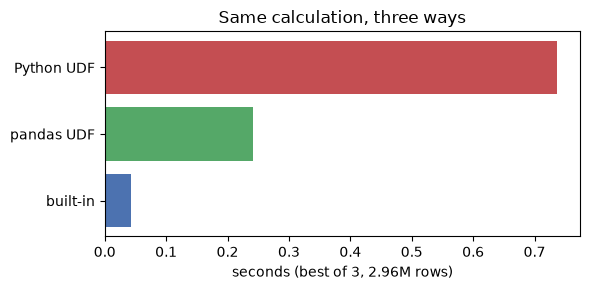

In [36]:
@F.udf(returnType=T.DoubleType())
def tip_pct_python(tip, fare):
    if tip is None or fare is None or fare <= 0:
        return None
    return 100.0 * tip / fare


@F.pandas_udf(T.DoubleType())
def tip_pct_pandas(tip: pd.Series, fare: pd.Series) -> pd.Series:
    return (100.0 * tip / fare).where(fare > 0)


tip_builtin = F.when(F.col("fare_amount") > 0, 100.0 * F.col("tip_amount") / F.col("fare_amount"))
money = jan.select("tip_amount", "fare_amount").cache()
money.count()                                                    # cache first so we time the function, not the file read

udf_timings, udf_sums = {}, {}
for name, expr in [("built-in", tip_builtin), ("pandas UDF", tip_pct_pandas("tip_amount", "fare_amount")),
                   ("Python UDF", tip_pct_python("tip_amount", "fare_amount"))]:
    runs = []
    for _ in range(3):
        start = time.perf_counter()
        udf_sums[name] = money.select(F.sum(expr)).first()[0]
        runs.append(time.perf_counter() - start)
    udf_timings[name] = min(runs)                                # best of 3 removes warm-up noise

for name, seconds in udf_timings.items():
    print(f"{name:10s} {seconds:6.3f}s  ({seconds / udf_timings['built-in']:4.1f}× built-in)  sum={udf_sums[name]:,.1f}")
assert math.isclose(udf_sums["built-in"], udf_sums["Python UDF"], rel_tol=1e-9) and math.isclose(udf_sums["built-in"], udf_sums["pandas UDF"], rel_tol=1e-9)

print()
for name, expr in [("Python UDF", tip_pct_python("tip_amount", "fare_amount")), ("pandas UDF", tip_pct_pandas("tip_amount", "fare_amount"))]:
    physical = plan_text(money.select(expr))
    print(f"{name}: plan operator →", "BatchEvalPython" if "BatchEvalPython" in physical else "ArrowEvalPython" if "ArrowEvalPython" in physical else "?")
money.unpersist()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(udf_timings), list(udf_timings.values()), color=["#4c72b0", "#55a868", "#c44e52"])
ax.set(xlabel="seconds (best of 3, 2.96M rows)", title="Same calculation, three ways")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

The Python UDF `distance_band` labels trips. Rewrite it with **built-in functions** (`F.when(...).when(...).otherwise(...)`) as the column expression `band_expr`, so the check can count trips per band.

In [37]:
@F.udf(returnType=T.StringType())
def distance_band(miles):
    if miles < 2:
        return "short"
    if miles < 10:
        return "medium"
    return "long"


band_expr = None  # TODO: a Column built with F.when(...)
band_counts = None if band_expr is None else jan.groupBy(band_expr.alias("band")).count().orderBy("band")
check("distance_bands", band_counts,
      duck_rows("SELECT CASE WHEN trip_distance < 2 THEN 'short' WHEN trip_distance < 10 THEN 'medium' ELSE 'long' END AS band, "
                "count(*) FROM {JAN} GROUP BY band ORDER BY band"),
      hint="F.when(F.col('trip_distance') < 2, 'short').when(F.col('trip_distance') < 10, 'medium').otherwise('long')")

⏳ distance_bands: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
band_expr = (F.when(F.col("trip_distance") < 2, "short")
             .when(F.col("trip_distance") < 10, "medium")
             .otherwise("long"))
band_counts = jan.groupBy(band_expr.alias("band")).count().orderBy("band")
check("distance_bands", band_counts,
      duck_rows("SELECT CASE WHEN trip_distance < 2 THEN 'short' WHEN trip_distance < 10 THEN 'medium' ELSE 'long' END AS band, "
                "count(*) FROM {JAN} GROUP BY band ORDER BY band"))
```

`trip_distance` has no nulls in this file; with nulls, the UDF would crash on `None < 2` while `F.when` would fall through to `otherwise`.
</details>

> 💡 **Interview angle:** "Our PySpark job is slow and full of UDFs." — replace them with built-in functions (Catalyst can optimize those and nothing leaves the JVM); if custom Python is unavoidable, use a **pandas UDF** so data moves in Arrow batches, and select only the needed columns before the UDF.

## 13. Window Functions 🟡

Window functions compute a value **per row using a group of related rows** without collapsing them — exactly like SQL's `OVER (PARTITION BY … ORDER BY …)` from the DuckDB notebook. Common uses: top-N per group, running totals, lag/lead differences, sessionization.

In [38]:
daily = (trips_clean.withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))
         .groupBy("pickup_date").agg(F.count("*").alias("trips")))

by_date_window = Window.orderBy("pickup_date")
daily_stats = (daily
               .withColumn("prev_day", F.lag("trips").over(by_date_window))
               .withColumn("change_pct", F.round(100 * (F.col("trips") - F.col("prev_day")) / F.col("prev_day"), 1))
               .withColumn("rolling_7d_avg", F.round(F.avg("trips").over(by_date_window.rowsBetween(-6, 0)), 0))
               .orderBy("pickup_date"))
daily_stats.show(10)

busiest = daily_stats.orderBy(F.desc("trips")).first()
quietest = daily_stats.orderBy("trips").first()
print(f"busiest day: {busiest['pickup_date']} ({busiest['trips']:,} trips) | quietest: {quietest['pickup_date']} ({quietest['trips']:,} trips)")

+-----------+------+--------+----------+--------------+
|pickup_date| trips|prev_day|change_pct|rolling_7d_avg|
+-----------+------+--------+----------+--------------+
| 2024-01-01| 75529|    NULL|      NULL|       75529.0|
| 2024-01-02| 73007|   75529|      -3.3|       74268.0|
| 2024-01-03| 79958|   73007|       9.5|       76165.0|
| 2024-01-04|100149|   79958|      25.3|       82161.0|
| 2024-01-05|100138|  100149|       0.0|       85756.0|
| 2024-01-06| 93769|  100138|      -6.4|       87092.0|
| 2024-01-07| 65224|   93769|     -30.4|       83968.0|
| 2024-01-08| 77744|   65224|      19.2|       84284.0|
| 2024-01-09| 90344|   77744|      16.2|       86761.0|
| 2024-01-10| 92519|   90344|       2.4|       88555.0|
+-----------+------+--------+----------+--------------+
only showing top 10 rows


busiest day: 2024-01-27 (107,219 trips) | quietest: 2024-01-07 (65,224 trips)


In [39]:
# Top-2 most expensive trips per pickup borough (ties broken by the earlier pickup)
per_borough = Window.partitionBy("pu_borough").orderBy(F.desc("total_amount"), "tpep_pickup_datetime")
(enriched.withColumn("rank", F.row_number().over(per_borough))
 .filter("rank <= 2")
 .select("pu_borough", "rank", "total_amount", "trip_distance", "duration_min")
 .orderBy("pu_borough", "rank")
 .show(14))

+-------------+----+------------+-------------+------------------+
|   pu_borough|rank|total_amount|trip_distance|      duration_min|
+-------------+----+------------+-------------+------------------+
|        Bronx|   1|       230.5|         35.7|55.333333333333336|
|        Bronx|   2|      213.44|        11.74|12.733333333333333|
|     Brooklyn|   1|       481.2|        23.07|31.233333333333334|
|     Brooklyn|   2|      433.61|       106.57|148.51666666666668|
|          EWR|   1|       204.7|        17.66|41.733333333333334|
|          EWR|   2|       197.5|        19.59|              37.8|
|    Manhattan|   1|      753.74|       120.76|             166.5|
|    Manhattan|   2|       586.6|         47.1| 68.36666666666666|
|          N/A|   1|       900.0|       157.25|150.61666666666667|
|          N/A|   2|      478.91|        49.93|             62.95|
|       Queens|   1|      940.93|       142.62|             160.1|
|       Queens|   2|      771.41|       119.46|146.38333333333

### ✍️ Your Turn

For **each borough**, find the pickup **zone** with the most January trips (use `jan` joined to `zones`; break ties by zone name). Return a DataFrame `top_zone_per_borough` with columns `(Borough, Zone, trips)`, ordered by `Borough`.

In [40]:
top_zone_per_borough = None  # TODO: groupBy → row_number over a window → filter
check("top_zone_per_borough", top_zone_per_borough,
      duck_rows("SELECT Borough, Zone, trips FROM (SELECT z.Borough, z.Zone, count(*) AS trips FROM {JAN} t "
                "JOIN {ZONES} z ON t.PULocationID = z.LocationID GROUP BY z.Borough, z.Zone) "
                "QUALIFY row_number() OVER (PARTITION BY Borough ORDER BY trips DESC, Zone) = 1 ORDER BY Borough"),
      hint="counts = jan.join(zones, jan.PULocationID == zones.LocationID).groupBy('Borough', 'Zone').agg(F.count('*').alias('trips'))")

⏳ top_zone_per_borough: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
counts = (jan.join(zones, jan.PULocationID == zones.LocationID)
          .groupBy("Borough", "Zone").agg(F.count("*").alias("trips")))
w = Window.partitionBy("Borough").orderBy(F.desc("trips"), "Zone")
top_zone_per_borough = (counts.withColumn("rn", F.row_number().over(w))
                        .filter("rn = 1").select("Borough", "Zone", "trips").orderBy("Borough"))
check("top_zone_per_borough", top_zone_per_borough,
      duck_rows("SELECT Borough, Zone, trips FROM (SELECT z.Borough, z.Zone, count(*) AS trips FROM {JAN} t "
                "JOIN {ZONES} z ON t.PULocationID = z.LocationID GROUP BY z.Borough, z.Zone) "
                "QUALIFY row_number() OVER (PARTITION BY Borough ORDER BY trips DESC, Zone) = 1 ORDER BY Borough"))
```

`row_number` gives exactly one winner per group; `rank` would keep ties.
</details>

> 💡 **Interview angle:** "Top-N per group on a huge table?" — `row_number()` over `partitionBy(group).orderBy(metric desc)` then filter. It shuffles by the group key, so a skewed group means a skewed task; for global top-N use `orderBy().limit(n)`, which Spark plans as a cheap `TakeOrderedAndProject`.

## 14. MLlib Pipelines 🟡

**MLlib** (`pyspark.ml`) trains models on DataFrames with the same *Estimator → Transformer → Pipeline* idea as scikit-learn:

- **Transformer**: `transform(df)` adds columns (e.g. `VectorAssembler` packs feature columns into one vector column).
- **Estimator**: `fit(df)` learns something and returns a Transformer (a model).
- **Pipeline**: a list of stages fit together, so the exact same preprocessing is applied at prediction time.

Quick demo: predict `fare_amount` from distance and duration. We split **by time** (first three weeks → train, last week → test), never randomly, because the model will be used on future trips.

In [41]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

fare_data = trips_clean.filter((F.col("duration_min") > 1) & (F.col("duration_min") < 180) & (F.col("trip_distance") < 100))
fare_train = fare_data.filter(F.col("tpep_pickup_datetime") < "2024-01-22").sample(fraction=0.1, seed=1)
fare_test = fare_data.filter(F.col("tpep_pickup_datetime") >= "2024-01-22").sample(fraction=0.1, seed=1)

fare_pipeline = Pipeline(stages=[
    VectorAssembler(inputCols=["trip_distance", "duration_min"], outputCol="features"),
    LinearRegression(featuresCol="features", labelCol="fare_amount"),
])
start = time.perf_counter()
fare_model = fare_pipeline.fit(fare_train)
fit_s = time.perf_counter() - start

rmse = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")
lr_stage = fare_model.stages[-1]
baseline_rmse = fare_test.select(F.sqrt(F.avg((F.col("fare_amount") - F.lit(fare_train.agg(F.avg("fare_amount")).first()[0])) ** 2))).first()[0]
test_rmse = rmse.evaluate(fare_model.transform(fare_test))
print(f"fit on {fare_train.count():,} rows in {fit_s:.1f}s")
print(f"fare ≈ {lr_stage.intercept:.2f} + {lr_stage.coefficients[0]:.2f}·miles + {lr_stage.coefficients[1]:.2f}·minutes")
print(f"test RMSE: model ${test_rmse:.2f} vs predict-the-mean baseline ${baseline_rmse:.2f}")

model_path = SPARK_DIR / "fare_pipeline_model"
fare_model.write().overwrite().save(str(model_path))
reloaded = PipelineModel.load(str(model_path))
same = reloaded.transform(fare_test.limit(5)).select("prediction").collect() == fare_model.transform(fare_test.limit(5)).select("prediction").collect()
print("saved to", model_path.as_posix(), "| reloaded model gives identical predictions:", same)

fit on 189,398 rows in 2.5s
fare ≈ 3.93 + 3.12·miles + 0.28·minutes
test RMSE: model $5.04 vs predict-the-mean baseline $16.41


saved to _outputs/spark/fare_pipeline_model | reloaded model gives identical predictions: True


> 💡 **Interview angle:** "When would you use Spark MLlib instead of scikit-learn/XGBoost?" — when the training data doesn't fit on one machine or the features already live in Spark; otherwise, a common pattern is to do feature engineering in Spark, write a sample or aggregate to Parquet, and train with scikit-learn/LightGBM on one machine (or use distributed XGBoost/LightGBM).

## 15. Spark Connect, Lakehouse Tables, and When Not to Use Spark 🟢

**Spark Connect** separates the client from the cluster: your Python process sends *unresolved plans* over gRPC to a remote Spark server (`SparkSession.builder.remote("sc://host:15002")`). Benefits: a thin client (`pip install pyspark-client`), no JVM on your laptop, better stability because a client crash can't take the driver down. It is how Databricks notebooks and serverless Spark work. Most DataFrame code is identical; low-level `RDD` and `SparkContext` APIs are **not** available in Connect — another reason to stick to the DataFrame API (this notebook only uses `rdd.getNumPartitions()` for inspection).

**Lakehouse table formats** add a transaction log on top of Parquet files:

| Feature | Plain Parquet folder | Delta Lake / Apache Iceberg |
|---|---|---|
| ACID commits, safe concurrent writers | ❌ (half-written files are visible) | ✅ |
| `UPDATE`, `DELETE`, `MERGE INTO` (upserts) | ❌ rewrite by hand | ✅ |
| Time travel (`VERSION AS OF`) | ❌ | ✅ |
| Schema evolution & enforcement | manual | ✅ |
| Small-file compaction | manual | `OPTIMIZE` / rewrite procedures |

Both need an extra connector package (`delta-spark`, or the Iceberg runtime JAR) that isn't installed here, so we only describe them.

In [42]:
import importlib.util

connect_ready = all(importlib.util.find_spec(m) is not None for m in ("grpc", "google.protobuf"))
print("Spark Connect client dependencies installed:", connect_ready)
print("delta-spark installed:", importlib.util.find_spec("delta") is not None)
print("⏭️ Skipped: no Spark Connect server or lakehouse connector is running in this notebook — the code above is local mode only.")

Spark Connect client dependencies installed: True
delta-spark installed: False
⏭️ Skipped: no Spark Connect server or lakehouse connector is running in this notebook — the code above is local mode only.


**When not to use Spark:** measure the same query — trips and average fare per pickup zone for January — in Spark, Polars and DuckDB on this one laptop.

In [43]:
def time_best(fn, repeats=3):
    best, result = float("inf"), None
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn()
        best = min(best, time.perf_counter() - start)
    return best, result


engine_results = {
    "Spark": time_best(lambda: sorted((r[0], r[1], r[2]) for r in jan.groupBy("PULocationID").agg(F.count("*"), F.avg("fare_amount")).collect())),
    "Polars": time_best(lambda: sorted(pl.scan_parquet(JAN).group_by("PULocationID").agg(pl.len(), pl.col("fare_amount").mean()).collect().rows())),
    "DuckDB": time_best(lambda: sorted(duck_rows("SELECT PULocationID, count(*), avg(fare_amount) FROM {JAN} GROUP BY 1"))),
}
reference = engine_results["DuckDB"][1]
for engine, (seconds, rows) in engine_results.items():
    agree = len(rows) == len(reference) and all(a[0] == b[0] and a[1] == b[1] and math.isclose(a[2], b[2], rel_tol=1e-9) for a, b in zip(rows, reference))
    print(f"{engine:6s} {seconds:6.3f}s | {len(rows)} zones | matches DuckDB: {agree}")
fastest = min(engine_results, key=lambda k: engine_results[k][0])
print(f"→ on ~3M rows on one machine, {fastest} is fastest; Spark is "
      f"{engine_results['Spark'][0] / engine_results[fastest][0]:.1f}× slower than {fastest} here." if fastest != "Spark" else "→ Spark was fastest here.")

Spark   0.068s | 260 zones | matches DuckDB: True
Polars  0.019s | 260 zones | matches DuckDB: True
DuckDB  0.010s | 260 zones | matches DuckDB: True
→ on ~3M rows on one machine, DuckDB is fastest; Spark is 6.8× slower than DuckDB here.


Spark pays for coordination (JVM, task scheduling, shuffle files) that only pays off when data or compute outgrows one machine, or when you need cluster fault tolerance and lakehouse integration. Rules of thumb:

- **Fits in RAM on one machine (≲ tens of GB)?** pandas / Polars / DuckDB — simpler and usually faster.
- **Hundreds of GB on one big machine?** Polars or DuckDB still often win.
- **Terabytes, many writers, a company data lake, or already on Databricks/EMR?** Spark.
- **Low-latency per-request work (an API)?** Not Spark — its job start-up alone takes seconds.

> 💡 **Interview angle:** "Would you use Spark for a 5 GB CSV?" — probably not: DuckDB or Polars on one machine will be simpler and faster. Mention the crossover: data larger than one machine, cluster fault tolerance, many concurrent pipelines, or an existing Spark/lakehouse platform.

## 🔧 Build It From Scratch

Interviewers love *"how does a distributed group-by actually work?"*. We implement it in plain Python over **Spark's own partitions**, then prove the result and even the shuffle placement match Spark.

### 1) A group-by as map → shuffle → reduce

```
 input partitions        MAP (per partition)          SHUFFLE (by hash of key)        REDUCE (per bucket)
 [rows of part 0] ──► {key: (sum, count)} ──┐        bucket 0 ◄── keys with pmod(hash,3)=0 ──► merge → (count, avg)
 [rows of part 1] ──► {key: (sum, count)} ──┼──►     bucket 1 ◄── …                        ──► merge
 [rows of part 2] ──► {key: (sum, count)} ──┘        bucket 2 ◄── …                        ──► merge
```

The map step already combines rows per key inside each partition (Spark's `partial_count` / `partial_avg`, like a MapReduce *combiner*), so far fewer records cross the network.

In [44]:
from collections import defaultdict

N_REDUCERS = 3
sample = (jan.select("PULocationID", "fare_amount").sample(fraction=0.02, seed=11)
          .withColumn("input_partition", F.spark_partition_id())
          .withColumn("key_hash", F.hash("PULocationID"))           # Spark's Murmur3 hash of the key
          .cache())
rows = sample.collect()

input_partitions = defaultdict(list)
for r in rows:
    input_partitions[r["input_partition"]].append((r["PULocationID"], r["fare_amount"], r["key_hash"]))


def map_phase(partition_rows):
    """Combine inside one partition: key → (sum, count). Keeps the key's hash for the shuffle."""
    combined = {}
    for key, fare, key_hash in partition_rows:
        total, count, _ = combined.get(key, (0.0, 0, key_hash))
        combined[key] = (total + fare, count + 1, key_hash)
    return [(key, key_hash, total, count) for key, (total, count, key_hash) in combined.items()]


def shuffle_phase(mapped_partitions, n_reducers):
    """Send every (key, partial result) to bucket pmod(hash, n). Python's % is already non-negative."""
    buckets = [[] for _ in range(n_reducers)]
    for mapped in mapped_partitions:
        for key, key_hash, total, count in mapped:
            buckets[key_hash % n_reducers].append((key, total, count))
    return buckets


def reduce_phase(bucket):
    merged = {}
    for key, total, count in bucket:
        t, c = merged.get(key, (0.0, 0))
        merged[key] = (t + total, c + count)
    return {key: (c, t / c) for key, (t, c) in merged.items()}


mapped = [map_phase(p) for p in input_partitions.values()]
buckets = shuffle_phase(mapped, N_REDUCERS)
ours = {}
for bucket in buckets:
    ours.update(reduce_phase(bucket))

spark_result = {r["PULocationID"]: (r["trips"], r["avg_fare"]) for r in
                sample.groupBy("PULocationID").agg(F.count("*").alias("trips"), F.avg("fare_amount").alias("avg_fare")).collect()}
assert ours.keys() == spark_result.keys()
assert all(ours[k][0] == spark_result[k][0] and math.isclose(ours[k][1], spark_result[k][1], rel_tol=1e-9) for k in ours)

# Our bucket for each key must equal the partition Spark's repartition(3, key) picks
spark_placement = {r["PULocationID"]: r["pid"] for r in
                   sample.repartition(N_REDUCERS, "PULocationID").select("PULocationID", F.spark_partition_id().alias("pid")).distinct().collect()}
our_placement = {key: b for b, bucket in enumerate(buckets) for key, _, _ in bucket}
assert our_placement == spark_placement

print(f"input rows: {len(rows):,} in {len(input_partitions)} partitions → records shuffled after map-side combine: {sum(len(m) for m in mapped):,}")
print(f"keys per reducer bucket: {[len({k for k, _, _ in b}) for b in buckets]}")
print(f"✅ {len(ours)} zones: counts and averages match Spark's groupBy, and every key landed in the same partition as repartition()")
sample.unpersist()

input rows: 59,274 in 3 partitions → records shuffled after map-side combine: 547
keys per reducer bucket: [77, 70, 72]
✅ 219 zones: counts and averages match Spark's groupBy, and every key landed in the same partition as repartition()


DataFrame[PULocationID: int, fare_amount: double, input_partition: int, key_hash: int]

### 2) Salting a skewed key, measured

Now the skew fix. We hash-partition a real sample of `payment_type` values into 4 partitions with a simple hash (CRC32), then add salts to keys that are too big for one partition, and measure how even the partitions become. A **two-stage aggregation** (group by key + salt, then by key) must give exactly the same counts.

hot keys: [1] (sample of 296,475 rows)
plain  partition loads: [4692, 58297, 0, 233486] → max/mean 3.15
salted partition loads: [76675, 59857, 101925, 58018] → max/mean 1.38
✅ salting cut the largest partition from 233,486 to 101,925 rows, and the two-stage counts are identical


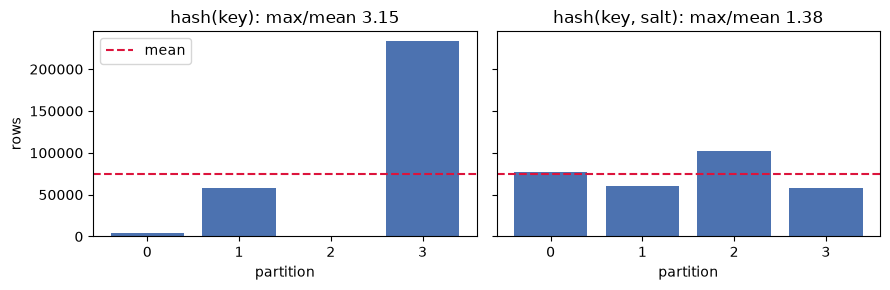

In [45]:
import zlib

N_PARTITIONS, N_SALTS = 4, 8
keys = [r[0] for r in jan.select("payment_type").sample(fraction=0.1, seed=3).collect()]
rng_salt = np.random.default_rng(0)


def partition_of(value, n):
    return zlib.crc32(str(value).encode()) % n


def loads(assignments, n):
    counts = [0] * n
    for a in assignments:
        counts[a] += 1
    return counts


key_counts = defaultdict(int)
for k in keys:
    key_counts[k] += 1
fair_share = len(keys) / N_PARTITIONS
hot = {k for k, c in key_counts.items() if c > fair_share}                 # keys bigger than one partition's fair share

salts = [int(rng_salt.integers(N_SALTS)) if k in hot else 0 for k in keys]
plain_loads = loads([partition_of(k, N_PARTITIONS) for k in keys], N_PARTITIONS)
salted_loads = loads([partition_of(f"{k}|{s}", N_PARTITIONS) for k, s in zip(keys, salts)], N_PARTITIONS)   # hash the combined key
plain_ratio = max(plain_loads) / np.mean(plain_loads)
salted_ratio = max(salted_loads) / np.mean(salted_loads)

# two-stage aggregation: count per (key, salt) … then per key
stage1 = defaultdict(int)
for k, s in zip(keys, salts):
    stage1[(k, s)] += 1
stage2 = defaultdict(int)
for (k, _), c in stage1.items():
    stage2[k] += c
assert dict(stage2) == dict(key_counts), "salting must not change the answer"

print(f"hot keys: {sorted(hot)} (sample of {len(keys):,} rows)")
print(f"plain  partition loads: {plain_loads} → max/mean {plain_ratio:.2f}")
print(f"salted partition loads: {salted_loads} → max/mean {salted_ratio:.2f}")
assert salted_ratio < plain_ratio
print(f"✅ salting cut the largest partition from {max(plain_loads):,} to {max(salted_loads):,} rows, and the two-stage counts are identical")

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
for ax, data, title in zip(axes, (plain_loads, salted_loads), (f"hash(key): max/mean {plain_ratio:.2f}", f"hash(key, salt): max/mean {salted_ratio:.2f}")):
    ax.bar(range(N_PARTITIONS), data, color="#4c72b0")
    ax.axhline(np.mean(data), ls="--", color="crimson", label="mean")
    ax.set(title=title, xlabel="partition", xticks=range(N_PARTITIONS))
axes[0].set_ylabel("rows")
axes[0].legend()
plt.tight_layout()
plt.show()

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Pulling big data to the driver

`collect()` and `toPandas()` copy rows into **one** Python process. On a cluster that is how drivers run out of memory. Aggregate in Spark and bring back only the answer.

In [46]:
start = time.perf_counter()
pulled = jan.select("PULocationID", "fare_amount").limit(500_000).collect()        # ❌ half a million Row objects
python_avg = {}
for r in pulled:
    s, c = python_avg.get(r["PULocationID"], (0.0, 0))
    python_avg[r["PULocationID"]] = (s + r["fare_amount"], c + 1)
wrong_s = time.perf_counter() - start
approx_mb = sum(sys.getsizeof(r) for r in pulled[:1000]) / 1000 * len(pulled) / 1e6
del pulled

start = time.perf_counter()
spark_avg = jan.limit(500_000).groupBy("PULocationID").agg(F.avg("fare_amount")).collect()   # ✅ only ~260 rows come back
right_s = time.perf_counter() - start
print(f"❌ collect 500k rows then loop in Python: {wrong_s:.2f}s, ~{approx_mb:.0f} MB of Row objects on the driver (the tuples alone)")
print(f"✅ aggregate in Spark, collect {len(spark_avg)} rows: {right_s:.2f}s")

❌ collect 500k rows then loop in Python: 0.95s, ~36 MB of Row objects on the driver (the tuples alone)
✅ aggregate in Spark, collect 240 rows: 0.20s


### ❌ Pitfall 2 — Division by zero under ANSI mode (Spark 4 default)

The January file has 893 trips with `fare_amount = 0`. In Spark 3 the division quietly returned `NULL`; in Spark 4 the whole job fails.

In [47]:
try:
    jan.select(F.avg(F.col("tip_amount") / F.col("fare_amount"))).first()          # ❌
except Exception as err:
    print("❌", type(err).__name__, "—", str(err).splitlines()[0][:110])

safe = jan.select(F.avg(F.try_divide(F.col("tip_amount"), F.col("fare_amount"))).alias("avg_tip_ratio")).first()[0]   # ✅
print(f"✅ try_divide skips the zero fares: average tip/fare ratio = {safe:.4f}")

❌ ArithmeticException — [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If ne
✅ try_divide skips the zero fares: average tip/fare ratio = 0.2281


### ❌ Pitfall 3 — A UDF with the wrong return type silently returns NULL

In [48]:
km_wrong = F.udf(lambda miles: miles * 1.609, T.IntegerType())                     # ❌ returns a float, declared int
km_right = F.udf(lambda miles: miles * 1.609, T.DoubleType())                      # ✅
checked = jan.limit(10_000).select(km_wrong("trip_distance").alias("wrong"), km_right("trip_distance").alias("right"))
nulls = checked.select(F.sum(F.col("wrong").isNull().cast("int")).alias("wrong_nulls"), F.sum(F.col("right").isNull().cast("int")).alias("right_nulls")).first()
print(f"❌ IntegerType UDF: {nulls['wrong_nulls']:,} of 10,000 values are NULL — no error raised")
print(f"✅ DoubleType UDF : {nulls['right_nulls']:,} NULLs   (and a built-in `F.col('trip_distance') * 1.609` would be faster still)")

❌ IntegerType UDF: 10,000 of 10,000 values are NULL — no error raised
✅ DoubleType UDF : 0 NULLs   (and a built-in `F.col('trip_distance') * 1.609` would be faster still)


### ❌ Pitfall 4 — Joining the same table twice without aliases

In [49]:
try:
    jan.join(zones, jan.PULocationID == zones.LocationID).join(zones, jan.DOLocationID == zones.LocationID).select("Zone").first()   # ❌
except Exception as err:
    print("❌", type(err).__name__, "—", str(err).splitlines()[0][:120])

pu, do = zones.alias("pu"), zones.alias("do")                                        # ✅ one alias per role
routes = (jan.alias("t")
          .join(pu, F.col("t.PULocationID") == F.col("pu.LocationID"))
          .join(do, F.col("t.DOLocationID") == F.col("do.LocationID"))
          .groupBy(F.col("pu.Zone").alias("pickup_zone"), F.col("do.Zone").alias("dropoff_zone")).count()
          .orderBy(F.desc("count")))
print("✅ busiest routes:")
routes.show(3, truncate=False)

❌ AnalysisException — Column LocationID#42 are ambiguous. It's probably because you joined several Datasets together, and some of these Datase


✅ busiest routes:


+---------------------+---------------------+-----+
|pickup_zone          |dropoff_zone         |count|
+---------------------+---------------------+-----+
|Upper East Side South|Upper East Side North|21883|
|Upper East Side North|Upper East Side South|19402|
|Upper East Side North|Upper East Side North|15955|
+---------------------+---------------------+-----+
only showing top 3 rows


### ❌ Pitfall 5 — Trusting that a monthly file only contains that month

In [50]:
by_month = (jan.groupBy(F.date_format("tpep_pickup_datetime", "yyyy-MM").alias("month")).count().orderBy("month"))
by_month.show()
file_rows = jan.count()                                                              # ❌ "January trips" = rows in the file
in_window = jan.filter((F.col("tpep_pickup_datetime") >= "2024-01-01") & (F.col("tpep_pickup_datetime") < "2024-02-01")).count()   # ✅
print(f"❌ rows in the January file: {file_rows:,} | ✅ trips that actually started in January: {in_window:,} ({file_rows - in_window} stray rows)")

+-------+-------+
|  month|  count|
+-------+-------+
|2002-12|      2|
|2009-01|      3|
|2023-12|     10|
|2024-01|2964606|
|2024-02|      3|
+-------+-------+

❌ rows in the January file: 2,964,624 | ✅ trips that actually started in January: 2,964,606 (18 stray rows)


A handful of rows looks harmless, but daily dashboards built on "rows per file" get phantom trips on 2002-12-31, and a time-based train/test split leaks future rows into training. Always filter to the period the file claims to cover.

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct. Expected answers are computed with DuckDB from the same files.

### 🟢 Exercise 1 — Big groups
How many **January file** trips have `passenger_count` of **5 or more**? Store the integer in `big_groups`.

In [51]:
big_groups = None  # TODO
check("big_groups", big_groups, duck_value("SELECT count(*) FROM {JAN} WHERE passenger_count >= 5"),
      hint="jan.filter(F.col('passenger_count') >= 5).count()")

⏳ big_groups: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
big_groups = jan.filter(F.col("passenger_count") >= 5).count()
check("big_groups", big_groups, duck_value("SELECT count(*) FROM {JAN} WHERE passenger_count >= 5"))
```
Rows with a `NULL` passenger count are dropped by the filter, because `NULL >= 5` is not true.
</details>

### 🟢 Exercise 2 — Average distance per vendor
Build `vendor_distance`: one row per `VendorID` with the average `trip_distance` (don't round), ordered by `VendorID`.

In [52]:
vendor_distance = None  # TODO
check("vendor_distance", vendor_distance,
      duck_rows("SELECT VendorID, avg(trip_distance) FROM {JAN} GROUP BY VendorID ORDER BY VendorID"),
      hint="jan.groupBy('VendorID').agg(F.avg('trip_distance')).orderBy('VendorID')")

⏳ vendor_distance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
vendor_distance = jan.groupBy("VendorID").agg(F.avg("trip_distance").alias("avg_distance")).orderBy("VendorID")
check("vendor_distance", vendor_distance,
      duck_rows("SELECT VendorID, avg(trip_distance) FROM {JAN} GROUP BY VendorID ORDER BY VendorID"))
```
</details>

### 🟢 Exercise 3 — Write a partitioned table
Write `zones` as Parquet **partitioned by `Borough`** to `zones_out` (overwrite mode), then count the `Borough=…` folders that were created and store the integer in `borough_folders`.

In [53]:
zones_out = SPARK_DIR / "exercises" / "zones_by_borough"
borough_folders = None  # TODO: write, then count folders with zones_out.glob("Borough=*")
check("borough_folders", borough_folders, duck_value("SELECT count(DISTINCT Borough) FROM {ZONES}"),
      hint="zones.write.mode('overwrite').partitionBy('Borough').parquet(str(zones_out))")

⏳ borough_folders: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
zones_out = SPARK_DIR / "exercises" / "zones_by_borough"
zones.write.mode("overwrite").partitionBy("Borough").parquet(str(zones_out))
borough_folders = len(list(zones_out.glob("Borough=*")))
check("borough_folders", borough_folders, duck_value("SELECT count(DISTINCT Borough) FROM {ZONES}"))
```
The borough `N/A` contains a slash, so Spark escapes the folder name as `Borough=N%2FA`.
</details>

### 🟡 Exercise 4 — Force a broadcast join
Automatic broadcasting is switched off inside this cell. Join `jan` to the **airport zones** (`zones` rows where `service_zone == "Airports"`) on the pickup zone, and force a **broadcast** so the plan uses `BroadcastHashJoin`. Store the joined DataFrame in `airport_trips`.

In [54]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
airport_zones = zones.filter(F.col("service_zone") == "Airports")
airport_trips = None  # TODO: jan.join(<broadcast the airport zones>, <condition>)
check("airport_broadcast", None if airport_trips is None else (join_strategy(airport_trips), airport_trips.count()),
      ("BroadcastHashJoin", duck_value("SELECT count(*) FROM {JAN} t JOIN {ZONES} z ON t.PULocationID = z.LocationID WHERE z.service_zone = 'Airports'")),
      hint="F.broadcast(airport_zones)")
spark.conf.unset("spark.sql.autoBroadcastJoinThreshold")

⏳ airport_broadcast: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
airport_zones = zones.filter(F.col("service_zone") == "Airports")
airport_trips = jan.join(F.broadcast(airport_zones), jan.PULocationID == airport_zones.LocationID)
check("airport_broadcast", (join_strategy(airport_trips), airport_trips.count()),
      ("BroadcastHashJoin", duck_value("SELECT count(*) FROM {JAN} t JOIN {ZONES} z ON t.PULocationID = z.LocationID WHERE z.service_zone = 'Airports'")))
spark.conf.unset("spark.sql.autoBroadcastJoinThreshold")
```
Hints beat the threshold. Without the hint, this plan would be a `SortMergeJoin`.
</details>

### 🟡 Exercise 5 — Two-stage salted aggregation
Compute the **total `fare_amount` per `payment_type`** for January, but aggregate in two stages: first group by `payment_type` **and** a random salt `0–7` (`F.floor(F.rand(seed=1) * 8)`), then group those partial sums by `payment_type`. Store the result in `salted_totals` with columns `(payment_type, total_fare)`, ordered by `payment_type`.

In [55]:
salted_totals = None  # TODO
check("salted_totals", salted_totals,
      duck_rows("SELECT payment_type, sum(fare_amount) FROM {JAN} GROUP BY payment_type ORDER BY payment_type"),
      hint="withColumn('salt', ...) → groupBy('payment_type', 'salt').agg(F.sum(...).alias('part')) → groupBy('payment_type').agg(F.sum('part'))")

⏳ salted_totals: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
salted_totals = (
    jan.withColumn("salt", F.floor(F.rand(seed=1) * 8))
    .groupBy("payment_type", "salt").agg(F.sum("fare_amount").alias("part"))
    .groupBy("payment_type").agg(F.sum("part").alias("total_fare"))
    .orderBy("payment_type")
)
check("salted_totals", salted_totals,
      duck_rows("SELECT payment_type, sum(fare_amount) FROM {JAN} GROUP BY payment_type ORDER BY payment_type"))
```
Two-stage aggregation works for sums, counts, min and max. For averages, carry `(sum, count)` through both stages; for exact distinct counts or medians it doesn't work directly.
</details>

### 🔴 Exercise 6 — Busiest hour of every day (interview classic)
For each **date in January 2024** (pickups from `2024-01-01` up to, not including, `2024-02-01`), find the pickup **hour** with the most trips (ties → the earliest hour). Return `busiest_hours` with columns `(pickup_date, hour, trips)`, ordered by `pickup_date` — 31 rows.

In [56]:
busiest_hours = None  # TODO: filter → groupBy(date, hour) → row_number over a window → filter
check("busiest_hours", busiest_hours,
      duck_rows("SELECT d, h, n FROM (SELECT CAST(tpep_pickup_datetime AS DATE) AS d, hour(tpep_pickup_datetime) AS h, count(*) AS n "
                "FROM {JAN} WHERE tpep_pickup_datetime >= TIMESTAMP '2024-01-01' AND tpep_pickup_datetime < TIMESTAMP '2024-02-01' "
                "GROUP BY d, h) QUALIFY row_number() OVER (PARTITION BY d ORDER BY n DESC, h) = 1 ORDER BY d"),
      hint="Window.partitionBy('pickup_date').orderBy(F.desc('trips'), 'hour')")

⏳ busiest_hours: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hourly = (jan.filter((F.col("tpep_pickup_datetime") >= "2024-01-01") & (F.col("tpep_pickup_datetime") < "2024-02-01"))
          .groupBy(F.to_date("tpep_pickup_datetime").alias("pickup_date"), F.hour("tpep_pickup_datetime").alias("hour"))
          .agg(F.count("*").alias("trips")))
w = Window.partitionBy("pickup_date").orderBy(F.desc("trips"), "hour")
busiest_hours = (hourly.withColumn("rn", F.row_number().over(w))
                 .filter("rn = 1").select("pickup_date", "hour", "trips").orderBy("pickup_date"))
check("busiest_hours", busiest_hours,
      duck_rows("SELECT d, h, n FROM (SELECT CAST(tpep_pickup_datetime AS DATE) AS d, hour(tpep_pickup_datetime) AS h, count(*) AS n "
                "FROM {JAN} WHERE tpep_pickup_datetime >= TIMESTAMP '2024-01-01' AND tpep_pickup_datetime < TIMESTAMP '2024-02-01' "
                "GROUP BY d, h) QUALIFY row_number() OVER (PARTITION BY d ORDER BY n DESC, h) = 1 ORDER BY d"))
```
Talk through it in an interview: filter first (pushdown), aggregate to at most 31 × 24 rows, **then** window — ranking the 3M raw rows would shuffle far more data.
</details>

## 🚀 Mini Project: NYC Taxi ETL, Analytics and Trip-Duration Model

**Goal:** turn two raw months of taxi trips into a clean, partitioned table; answer business questions with Spark SQL; inspect the plans; prove the numbers with three other engines; and train an MLlib model that predicts **trip duration** for **future** trips — with a strict time-based split and a single test evaluation.

**Steps:** extract & validate → transform & load → analytics → inspect plans → cross-check with pandas / Polars / DuckDB → MLlib model (train Jan 1–24, validate Jan 25–31, test on February once) → conclusions → clean up.

### Step 1 — Extract and validate

Each file keeps only pickups inside its own month (Pitfall 5). Then we count how many rows break each quality rule in **one** aggregate pass.

In [57]:
def load_month(path, start, end):
    return spark.read.parquet(str(path)).filter((F.col("tpep_pickup_datetime") >= start) & (F.col("tpep_pickup_datetime") < end))


raw = load_month(JAN, "2024-01-01", "2024-02-01").unionByName(load_month(FEB, "2024-02-01", "2024-03-01"))
raw = raw.withColumn("duration_min", (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)

UNKNOWN_ZONES = [264, 265]                                        # "Unknown" and "Outside of NYC" in the lookup
rules = {
    "fare_positive": F.col("fare_amount") > 0,
    "distance_0_100": (F.col("trip_distance") > 0) & (F.col("trip_distance") < 100),
    "duration_1_180": (F.col("duration_min") >= 1) & (F.col("duration_min") <= 180),
    "known_zones": ~F.col("PULocationID").isin(UNKNOWN_ZONES) & ~F.col("DOLocationID").isin(UNKNOWN_ZONES),
}
report = raw.select(F.count("*").alias("rows"),
                    *[F.sum((~rule).cast("int")).alias(f"fails_{name}") for name, rule in rules.items()]).first().asDict()
all_rules = rules["fare_positive"] & rules["distance_0_100"] & rules["duration_1_180"] & rules["known_zones"]
valid = raw.filter(all_rules)
n_raw, n_valid = report.pop("rows"), valid.count()
for name, fails in report.items():
    print(f"{name:22s} {fails:9,} rows ({fails / n_raw:.2%})")
print(f"kept {n_valid:,} of {n_raw:,} rows ({n_valid / n_raw:.1%})")

fails_fare_positive       79,838 rows (1.34%)
fails_distance_0_100     128,725 rows (2.16%)
fails_duration_1_180      72,795 rows (1.22%)
fails_known_zones         60,497 rows (1.01%)
kept 5,697,179 of 5,972,117 rows (95.4%)


### Step 2 — Transform and load a partitioned table

Add features, attach borough names with **broadcast** joins (one alias per role), and write Parquet partitioned by `pickup_date`, one file per day.

In [58]:
pu_zone = F.broadcast(zones.select(F.col("LocationID").alias("PULocationID"), F.col("Borough").alias("pu_borough"),
                                   F.col("service_zone").alias("pu_service_zone")))
do_zone = F.broadcast(zones.select(F.col("LocationID").alias("DOLocationID"), F.col("Borough").alias("do_borough"),
                                   F.col("service_zone").alias("do_service_zone")))

curated = (
    valid.join(pu_zone, "PULocationID").join(do_zone, "DOLocationID")
    .withColumn("pickup_date", F.to_date("tpep_pickup_datetime"))
    .withColumn("hour", F.hour("tpep_pickup_datetime"))
    .withColumn("dow", F.dayofweek("tpep_pickup_datetime"))                 # 1 = Sunday … 7 = Saturday
    .withColumn("is_weekend", F.col("dow").isin(1, 7))
    .withColumn("is_airport", (F.col("pu_service_zone") == "Airports") | (F.col("do_service_zone") == "Airports") |
                (F.col("pu_service_zone") == "EWR") | (F.col("do_service_zone") == "EWR"))
    .withColumn("speed_mph", F.col("trip_distance") / (F.col("duration_min") / 60))
    .withColumn("tip_pct", F.when(F.col("payment_type") == 1, 100 * F.col("tip_amount") / F.col("fare_amount")))
    .select("pickup_date", "tpep_pickup_datetime", "hour", "dow", "is_weekend", "PULocationID", "DOLocationID", "pu_borough", "do_borough",
            "is_airport", "trip_distance", "duration_min", "speed_mph", "fare_amount", "tip_pct", "payment_type", "total_amount")
)
print("ETL join strategies:", plan_text(curated).count("BroadcastHashJoin"), "× BroadcastHashJoin")

CURATED_PATH = SPARK_DIR / "curated_trips"
start = time.perf_counter()
curated.repartition("pickup_date").write.mode("overwrite").partitionBy("pickup_date").parquet(str(CURATED_PATH))
print(f"wrote {len(list(CURATED_PATH.glob('pickup_date=*')))} daily partitions to {CURATED_PATH.as_posix()} in {time.perf_counter() - start:.1f}s")

trips = spark.read.parquet(str(CURATED_PATH))
trips.createOrReplaceTempView("trips")
assert trips.count() == n_valid, "every valid row should land in the curated table exactly once"
print(f"curated rows: {n_valid:,} ✅ matches the validated count")

ETL join strategies: 2 × BroadcastHashJoin


wrote 60 daily partitions to _outputs/spark/curated_trips in 5.6s


curated rows: 5,697,179 ✅ matches the validated count


### Step 3 — Analytics with Spark SQL

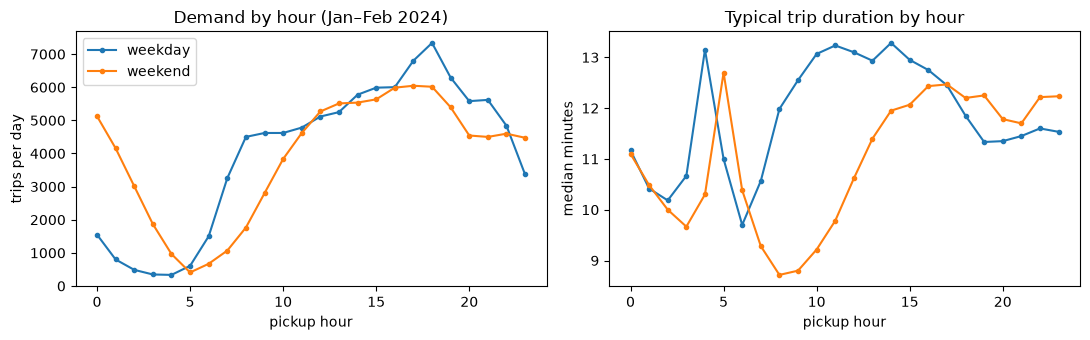

In [59]:
hourly = spark.sql("""
    SELECT hour, is_weekend,
           COUNT(*) / COUNT(DISTINCT pickup_date)      AS trips_per_day,
           percentile_approx(duration_min, 0.5)        AS median_duration,
           AVG(speed_mph)                              AS avg_speed
    FROM trips
    GROUP BY hour, is_weekend
    ORDER BY is_weekend, hour
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for weekend, label in [(False, "weekday"), (True, "weekend")]:
    part = hourly[hourly["is_weekend"] == weekend]
    axes[0].plot(part["hour"], part["trips_per_day"], marker="o", ms=3, label=label)
    axes[1].plot(part["hour"], part["median_duration"], marker="o", ms=3, label=label)
axes[0].set(xlabel="pickup hour", ylabel="trips per day", title="Demand by hour (Jan–Feb 2024)")
axes[1].set(xlabel="pickup hour", ylabel="median minutes", title="Typical trip duration by hour")
axes[0].legend()
plt.tight_layout()
plt.show()

In [60]:
airport = spark.sql("""
    SELECT is_airport, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare, ROUND(AVG(trip_distance), 2) AS avg_miles,
           ROUND(percentile_approx(tip_pct, 0.5), 1) AS median_card_tip_pct
    FROM trips GROUP BY is_airport ORDER BY is_airport
""")
airport.show()

flows = spark.sql("""
    SELECT pu_borough, do_borough, COUNT(*) AS trips, ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_all
    FROM trips GROUP BY pu_borough, do_borough ORDER BY trips DESC LIMIT 5
""")
flows.show()

peak = hourly[~hourly["is_weekend"]].sort_values("trips_per_day").iloc[-1]
slowest = hourly[~hourly["is_weekend"]].sort_values("avg_speed").iloc[0]
airport_rows = {r["is_airport"]: r for r in airport.collect()}
top_flow = flows.first()

+----------+-------+--------+---------+-------------------+
|is_airport|  trips|avg_fare|avg_miles|median_card_tip_pct|
+----------+-------+--------+---------+-------------------+
|     false|5168214|   14.39|     2.16|               26.6|
|      true| 528965|   54.61|     13.4|               23.1|
+----------+-------+--------+---------+-------------------+



+----------+----------+-------+----------+
|pu_borough|do_borough|  trips|pct_of_all|
+----------+----------+-------+----------+
| Manhattan| Manhattan|4878781|     85.64|
|    Queens| Manhattan| 287299|      5.04|
| Manhattan|    Queens| 149788|      2.63|
| Manhattan|  Brooklyn| 107277|      1.88|
|    Queens|    Queens|  99219|      1.74|
+----------+----------+-------+----------+



### Step 4 — Inspect the plans

A dashboard query for one week should read only 7 daily folders and 3 columns. Let's verify instead of hoping.

In [61]:
week_query = (trips.filter((F.col("pickup_date") >= "2024-02-05") & (F.col("pickup_date") <= "2024-02-11"))
              .groupBy("pu_borough").agg(F.avg("duration_min").alias("avg_duration")))
week_plan = plan_text(week_query)
show_plan(week_query)
partition_filters = re.search(r"PartitionFilters: \[(.*?)\]", week_plan).group(1)
read_schema = re.search(r"ReadSchema: (struct<[^>]*>)", week_plan).group(1)
print("\nPartitionFilters:", partition_filters)
print("ReadSchema      :", read_schema)
assert "pickup_date" in partition_filters and read_schema.count(":") == 2
print("✅ partition pruning on pickup_date and only 2 data columns read (pickup_date comes from folder names)")

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[pu_borough#6987], functions=[avg(duration_min#6991)])
   +- Exchange hashpartitioning(pu_borough#6987, 8), ENSURE_REQUIREMENTS, [plan_id=8412]
      +- HashAggregate(keys=[pu_borough#6987], functions=[partial_avg(duration_min#6991)])
         +- Project [pu_borough#6987, duration_min#6991]
            +- FileScan parquet [pu_borough#6987,duration_min#6991,pickup_date#6997] Batched: true, DataFilters: [], Format: Parquet, Location: InMemo …

PartitionFilters: isnotnull(pickup_date#6997), (pickup_date#6997 >= 2024-02-05), (pickup_date#6997 <= 2024-02-11)
ReadSchema      : struct<pu_borough:string,duration_min:double>
✅ partition pruning on pickup_date and only 2 data columns read (pickup_date comes from folder names)


### Step 5 — Cross-check with pandas, Polars and DuckDB

Recompute **trips, mean duration and mean fare per hour for the first week of February** straight from the raw file with the same cleaning rules in three other engines. Independent implementations agreeing is the strongest evidence the ETL is right.

In [62]:
WEEK_START, WEEK_END = "2024-02-01", "2024-02-08"

spark_week = sorted(tuple(r) for r in trips.filter((F.col("pickup_date") >= WEEK_START) & (F.col("pickup_date") < WEEK_END))
                    .groupBy("hour").agg(F.count("*"), F.avg("duration_min"), F.avg("fare_amount")).collect())

duck_week = sorted(duck.sql(f"""
    WITH t AS (SELECT *, (epoch(tpep_dropoff_datetime) - epoch(tpep_pickup_datetime)) / 60 AS duration_min FROM {DUCK_FILES['FEB']}
               WHERE tpep_pickup_datetime >= TIMESTAMP '{WEEK_START}' AND tpep_pickup_datetime < TIMESTAMP '{WEEK_END}')
    SELECT hour(tpep_pickup_datetime) AS hour, count(*), avg(duration_min), avg(fare_amount) FROM t
    WHERE fare_amount > 0 AND trip_distance > 0 AND trip_distance < 100 AND duration_min BETWEEN 1 AND 180
      AND PULocationID NOT IN (264, 265) AND DOLocationID NOT IN (264, 265)
    GROUP BY 1
""").fetchall())

polars_week = sorted(
    pl.scan_parquet(FEB)
    .filter((pl.col("tpep_pickup_datetime") >= pl.datetime(2024, 2, 1)) & (pl.col("tpep_pickup_datetime") < pl.datetime(2024, 2, 8)))
    .with_columns(((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60).alias("duration_min"))
    .filter((pl.col("fare_amount") > 0) & (pl.col("trip_distance") > 0) & (pl.col("trip_distance") < 100)
            & pl.col("duration_min").is_between(1, 180) & ~pl.col("PULocationID").is_in(UNKNOWN_ZONES) & ~pl.col("DOLocationID").is_in(UNKNOWN_ZONES))
    .group_by(pl.col("tpep_pickup_datetime").dt.hour().cast(pl.Int32).alias("hour"))
    .agg(pl.len(), pl.col("duration_min").mean(), pl.col("fare_amount").mean())
    .collect().rows()
)

pdf = pd.read_parquet(FEB, columns=["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "fare_amount", "PULocationID", "DOLocationID"])
pdf = pdf[(pdf["tpep_pickup_datetime"] >= WEEK_START) & (pdf["tpep_pickup_datetime"] < WEEK_END)]
pdf = pdf.assign(duration_min=(pdf["tpep_dropoff_datetime"] - pdf["tpep_pickup_datetime"]).dt.total_seconds() / 60)
pdf = pdf[(pdf["fare_amount"] > 0) & (pdf["trip_distance"] > 0) & (pdf["trip_distance"] < 100) & pdf["duration_min"].between(1, 180)
          & ~pdf["PULocationID"].isin(UNKNOWN_ZONES) & ~pdf["DOLocationID"].isin(UNKNOWN_ZONES)]
pandas_week = sorted(pdf.groupby(pdf["tpep_pickup_datetime"].dt.hour).agg(n=("fare_amount", "size"), d=("duration_min", "mean"), f=("fare_amount", "mean"))
                     .itertuples(name=None))
del pdf


def same_table(a, b):
    return len(a) == len(b) and all(x[0] == y[0] and x[1] == y[1] and math.isclose(x[2], y[2], rel_tol=1e-9) and math.isclose(x[3], y[3], rel_tol=1e-9)
                                    for x, y in zip(a, b))


for engine, table in [("DuckDB", duck_week), ("Polars", polars_week), ("pandas", pandas_week)]:
    print(f"Spark vs {engine:6s}: {'✅ identical' if same_table(spark_week, table) else '❌ different'} ({sum(r[1] for r in table):,} trips, 24 hours)")
assert all(same_table(spark_week, t) for t in (duck_week, polars_week, pandas_week))

Spark vs DuckDB: ✅ identical (679,020 trips, 24 hours)
Spark vs Polars: ✅ identical (679,020 trips, 24 hours)
Spark vs pandas: ✅ identical (679,020 trips, 24 hours)


### Step 6 — MLlib: predict trip duration for future trips

- **Train:** Jan 1–24 · **Validation:** Jan 25–31 (model selection) · **Test:** all of February, used **once**.
- Features known at pickup time: distance (from the booked route), hour, day of week, weekend flag, pickup/drop-off borough, airport flag.
- Candidates: a mean-duration baseline, linear regression (one-hot boroughs), and gradient-boosted trees. We sample the training weeks (8%) to keep the laptop run short.

In [63]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml.regression import GBTRegressor

model_data = trips.select("tpep_pickup_datetime", "duration_min", "trip_distance", "hour", "dow",
                          F.col("is_weekend").cast("double").alias("weekend"), F.col("is_airport").cast("double").alias("airport"),
                          "pu_borough", "do_borough")
train_df = model_data.filter(F.col("tpep_pickup_datetime") < "2024-01-25").sample(fraction=0.08, seed=42).cache()
val_df = model_data.filter((F.col("tpep_pickup_datetime") >= "2024-01-25") & (F.col("tpep_pickup_datetime") < "2024-02-01")).sample(fraction=0.2, seed=42).cache()
test_df = model_data.filter(F.col("tpep_pickup_datetime") >= "2024-02-01")
print(f"train rows {train_df.count():,} | validation rows {val_df.count():,} | test rows (February) {test_df.count():,}")
assert train_df.agg(F.max("tpep_pickup_datetime")).first()[0] < val_df.agg(F.min("tpep_pickup_datetime")).first()[0]

indexer = StringIndexer(inputCols=["pu_borough", "do_borough"], outputCols=["pu_idx", "do_idx"], handleInvalid="keep")
numeric = ["trip_distance", "hour", "dow", "weekend", "airport"]
candidates = {
    "linear regression": Pipeline(stages=[
        indexer, OneHotEncoder(inputCols=["pu_idx", "do_idx"], outputCols=["pu_vec", "do_vec"], handleInvalid="keep"),
        VectorAssembler(inputCols=numeric + ["pu_vec", "do_vec"], outputCol="features"),
        LinearRegression(featuresCol="features", labelCol="duration_min")]),
    "gradient-boosted trees": Pipeline(stages=[
        indexer, VectorAssembler(inputCols=numeric + ["pu_idx", "do_idx"], outputCol="features"),
        GBTRegressor(featuresCol="features", labelCol="duration_min", maxIter=40, maxDepth=6, seed=42)]),
}
rmse_eval = RegressionEvaluator(labelCol="duration_min", metricName="rmse")
mae_eval = RegressionEvaluator(labelCol="duration_min", metricName="mae")

train_mean = train_df.agg(F.avg("duration_min")).first()[0]
val_scores = {"mean baseline": rmse_eval.evaluate(val_df.withColumn("prediction", F.lit(train_mean)))}
fit_seconds = {}
for name, pipeline in candidates.items():
    start = time.perf_counter()
    fitted = pipeline.fit(train_df)
    fit_seconds[name] = time.perf_counter() - start
    val_scores[name] = rmse_eval.evaluate(fitted.transform(val_df))
for name, score in val_scores.items():
    print(f"validation RMSE {score:6.2f} min | {name}" + (f" (fit {fit_seconds[name]:.1f}s)" if name in fit_seconds else ""))
winner = min(candidates, key=val_scores.get)
print(f"🏆 chosen on validation: {winner}")

train rows 171,961 | validation rows 135,715 | test rows (February) 2,865,801


validation RMSE  11.62 min | mean baseline
validation RMSE   6.77 min | linear regression (fit 2.6s)
validation RMSE   5.46 min | gradient-boosted trees (fit 11.1s)
🏆 chosen on validation: gradient-boosted trees


In [64]:
# Refit the winner on train + validation weeks, then the single evaluation on February
final_train = model_data.filter(F.col("tpep_pickup_datetime") < "2024-02-01").sample(fraction=0.08, seed=7)
start = time.perf_counter()
final_model = candidates[winner].fit(final_train)
final_fit_s = time.perf_counter() - start
test_pred = final_model.transform(test_df).cache()
test_rmse, test_mae = rmse_eval.evaluate(test_pred), mae_eval.evaluate(test_pred)
baseline_test = test_df.withColumn("prediction", F.lit(final_train.agg(F.avg("duration_min")).first()[0]))
base_rmse, base_mae = rmse_eval.evaluate(baseline_test), mae_eval.evaluate(baseline_test)
print(f"final fit {final_fit_s:.1f}s | February test: RMSE {test_rmse:.2f} min, MAE {test_mae:.2f} min | "
      f"mean baseline RMSE {base_rmse:.2f}, MAE {base_mae:.2f}")

by_borough_error = (test_pred.groupBy("pu_borough").agg(F.count("*").alias("trips"), F.avg(F.abs(F.col("prediction") - F.col("duration_min"))).alias("mae"))
                    .filter("trips >= 1000").orderBy("mae"))
by_borough_error.show()
test_pred.unpersist(); train_df.unpersist(); val_df.unpersist()

final fit 8.6s | February test: RMSE 5.66 min, MAE 3.50 min | mean baseline RMSE 12.00, MAE 8.27
+----------+-------+------------------+
|pu_borough|  trips|               mae|
+----------+-------+------------------+
| Manhattan|2608273| 3.141516178564391|
|    Queens| 227176| 6.722824175099541|
|  Brooklyn|  24553|  9.74674572697536|
|     Bronx|   5749|13.329220205545026|
+----------+-------+------------------+



DataFrame[tpep_pickup_datetime: timestamp_ntz, duration_min: double, trip_distance: double, hour: int, dow: int, weekend: double, airport: double, pu_borough: string, do_borough: string]

### Step 7 — Conclusions (computed)

In [65]:
kept_pct = n_valid / n_raw
worst_rule = max(report, key=report.get)
print(f"1. Data quality: kept {kept_pct:.1%} of {n_raw:,} raw trips; the rule removing the most rows was '{worst_rule}' ({report[worst_rule]:,}).")
print(f"2. Weekday demand peaks at {int(peak['hour'])}:00 with ~{peak['trips_per_day']:,.0f} trips per day; the slowest average speed is at "
      f"{int(slowest['hour'])}:00 ({slowest['avg_speed']:.1f} mph).")
print(f"3. Airport trips average ${airport_rows[True]['avg_fare']:.2f} vs ${airport_rows[False]['avg_fare']:.2f} for other trips "
      f"({airport_rows[True]['avg_miles']:.1f} vs {airport_rows[False]['avg_miles']:.1f} miles).")
print(f"4. The biggest flow is {top_flow['pu_borough']} → {top_flow['do_borough']} with {top_flow['pct_of_all']}% of all trips.")
print(f"5. Spark's hourly numbers for Feb 1–7 match DuckDB, Polars and pandas exactly; the week query pruned partitions and read 2 columns.")
improvement = 1 - test_rmse / base_rmse
print(f"6. {winner} was chosen on validation; on February it reaches RMSE {test_rmse:.2f} min vs {base_rmse:.2f} for the mean baseline "
      f"({improvement:.0%} lower) → {'a useful model' if improvement > 0.3 else 'only a modest gain over the baseline'}.")
val_gap = test_rmse - val_scores[winner]
print(f"7. Test RMSE is {abs(val_gap):.2f} min {'higher' if val_gap > 0 else 'lower'} than validation "
      f"→ {'stable across the month boundary' if abs(val_gap) < 1 else 'noticeable drift between January and February'}.")

1. Data quality: kept 95.4% of 5,972,117 raw trips; the rule removing the most rows was 'fails_distance_0_100' (128,725).
2. Weekday demand peaks at 18:00 with ~7,338 trips per day; the slowest average speed is at 11:00 (9.4 mph).
3. Airport trips average $54.61 vs $14.39 for other trips (13.4 vs 2.2 miles).
4. The biggest flow is Manhattan → Manhattan with 85.64% of all trips.
5. Spark's hourly numbers for Feb 1–7 match DuckDB, Polars and pandas exactly; the week query pruned partitions and read 2 columns.
6. gradient-boosted trees was chosen on validation; on February it reaches RMSE 5.66 min vs 12.00 for the mean baseline (53% lower) → a useful model.
7. Test RMSE is 0.20 min higher than validation → stable across the month boundary.


**Stretch goals**
1. Add **route features**: average historical duration per (pickup zone, drop-off zone, hour) computed on the **training weeks only**, joined in as a feature. How much does RMSE drop, and why must the averages exclude validation/test weeks?
2. Tune `maxDepth` / `maxIter` with `pyspark.ml.tuning.TrainValidationSplit` — but with your own **time-based** validation set, not its random split.
3. Write the curated table as **Delta Lake** (`pip install delta-spark`), then run `MERGE INTO` to upsert a corrected day and query an old version with time travel.
4. Load March 2024 and append it with `partitionOverwriteMode=dynamic`; confirm January and February folders are untouched.
5. Open the Spark UI during Step 2 and find the stage with the largest shuffle write. Can you remove that shuffle?

### 🗣️ How to talk about this in an interview
- "I built a batch ETL in PySpark: per-file month filters, four data-quality rules measured in one aggregate pass, broadcast joins to the zone dimension, and a Parquet table partitioned by date with one file per day."
- "I verified performance claims from the plans: `BroadcastHashJoin` in the ETL, `PartitionFilters` on `pickup_date` and a two-column `ReadSchema` for the dashboard query."
- "To trust the pipeline I cross-checked a week of hourly metrics against DuckDB, Polars and pandas computed from the raw file. All matched exactly."
- "For the duration model I used a strict time-based split — train on Jan 1–24, pick the model on Jan 25–31, refit, and score February once — and compared against a mean baseline."
- "Next steps would be route-level target statistics computed only on training data, Delta Lake for idempotent upserts, and moving the model to LightGBM on a sample if MLlib's accuracy isn't enough."

### Step 8 — Clean up

Stop the session to free the JVM's memory and threads. (Re-run the Setup cell to start again.)

In [66]:
spark.stop()
print("Spark session stopped. Files written by this notebook are under", SPARK_DIR.as_posix())

Spark session stopped. Files written by this notebook are under _outputs/spark


## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is lazy evaluation in Spark, and what actually happens when you call an action?**

<details><summary>Show answer</summary>

- **30-second answer:** Transformations only build a logical plan. An action (`count`, `collect`, `write`) makes Spark analyze and optimize the whole plan with Catalyst, pick physical operators, cut it into stages at shuffle boundaries, and run one task per partition on the executors.
- **Go deeper:** Seeing the whole query enables predicate pushdown, column pruning and join-strategy selection. Lineage (the recipe for each partition) is what lets Spark recompute lost partitions after an executor failure. Because nothing runs until an action, bugs in transformations surface late — and every action re-runs the plan unless results are cached.
- **❌ Common wrong answer:** "Each transformation runs immediately but results are kept in memory."

</details>

**Q2. Narrow vs wide transformations — why does the difference matter?**

<details><summary>Show answer</summary>

- **30-second answer:** Narrow transformations (`filter`, `select`, `withColumn`) map each input partition to one output partition with no data movement. Wide transformations (`groupBy`, `join`, `distinct`, `orderBy`, `repartition`) need rows with the same key together, so they **shuffle** data across the network and start a new stage.
- **Go deeper:** Shuffles write intermediate files to disk, serialize data, and move it between executors, so they dominate runtime and are where skew and out-of-memory errors appear. In `explain()` each shuffle is an `Exchange` node. Minimize shuffles: filter and project early, broadcast small tables, and avoid unnecessary `repartition`.
- **❌ Common wrong answer:** "`groupBy` is narrow because it only reads one column."

</details>

**Q3. Explain Spark's join strategies and how Spark picks one.**

<details><summary>Show answer</summary>

- **30-second answer:** **Broadcast hash join** ships the small side to every executor, so there is no shuffle of the big side. It's chosen when a side's estimated size is under `spark.sql.autoBroadcastJoinThreshold` (10 MB) or when hinted. **Sort-merge join** shuffles and sorts both sides and is the default for large equi-joins. **Shuffle hash join** shuffles both sides and hashes the smaller one per partition, chosen via hint or when sort-merge isn't preferred. Non-equi joins fall back to nested-loop joins.
- **Go deeper:** Hints: `F.broadcast(df)`, `df.hint("shuffle_hash")`, `"merge"`. AQE can switch a sort-merge join to broadcast at runtime once the real size is known. You can't broadcast the preserved side of an outer join. Broadcasting something too big causes driver/executor OOM or broadcast timeouts.
- **❌ Common wrong answer:** "Spark always uses a hash join" or "broadcast the big table to make it faster."

</details>

**Q4. What is Adaptive Query Execution (AQE)?**

<details><summary>Show answer</summary>

- **30-second answer:** Runtime re-optimization, on by default since Spark 3.2. After each shuffle stage, Spark uses the real partition sizes to (1) **coalesce** small shuffle partitions, (2) **switch** sort-merge joins to broadcast joins when a side turns out small, and (3) **split skewed partitions** in sort-merge joins.
- **Go deeper:** In `explain()` you see `AdaptiveSparkPlan isFinalPlan=false` before running and `true` after, with nodes like `AQEShuffleRead coalesced` and `SortMergeJoin(skew=true)`. Key configs: `spark.sql.adaptive.advisoryPartitionSizeInBytes` (64 MB), `skewJoin.skewedPartitionFactor` (5) and `skewedPartitionThresholdInBytes` (256 MB). With AQE, `spark.sql.shuffle.partitions` acts as an upper bound.
- **❌ Common wrong answer:** "AQE is the cost-based optimizer that uses table statistics before the query starts."

</details>

**Q5. What do Catalyst and Tungsten do?**

<details><summary>Show answer</summary>

- **30-second answer:** **Catalyst** is the query optimizer: parsed → analyzed → optimized logical plan (rule-based rewrites like predicate pushdown, column pruning, constant folding) → physical plan (with cost-based choices such as join strategies). **Tungsten** is the execution layer: compact binary rows, explicit memory management, and whole-stage code generation that fuses operators into one compiled function.
- **Go deeper:** That's why DataFrame/SQL code is fast in any language — Python only describes the plan. `*(n)` in plans marks whole-stage codegen. Python UDFs are opaque to Catalyst, so filters can't be pushed through them and they break codegen.
- **❌ Common wrong answer:** "PySpark DataFrames are slower than Scala DataFrames because Python runs the operations."

</details>

**Q6. When does caching help, and when does it hurt?**

<details><summary>Show answer</summary>

- **30-second answer:** It helps when an expensive intermediate result is reused by several actions (iterative ML, exploratory queries after a heavy join). It hurts for one-off use or cheap sources: building the cache costs a full pass and executor memory, and scans of the cache lose Parquet pushdown and column pruning.
- **Go deeper:** `DataFrame.cache()` uses `MEMORY_AND_DISK` (deserialized) by default. `persist(StorageLevel.DISK_ONLY)` avoids memory pressure. Cached data can be evicted, so it is not a durability guarantee — use `checkpoint()` or write to storage to cut long lineages. Always `unpersist()`. In this notebook, caching a one-off filter was slower than reading Parquet directly.
- **❌ Common wrong answer:** "Cache everything; memory is faster than disk."

</details>

**Q7. Built-in functions vs Python UDFs vs pandas UDFs?**

<details><summary>Show answer</summary>

- **30-second answer:** Built-ins run inside the JVM and are optimized and code-generated, so they're fastest. Python UDFs serialize every row to a Python worker and back, so they're slowest and opaque to the optimizer. Pandas UDFs send Arrow columnar batches and run vectorized pandas code — much faster than row UDFs when custom Python is unavoidable.
- **Go deeper:** We measured the same tip-percentage calculation: built-in fastest, pandas UDF next, Python UDF slowest (plan nodes `BatchEvalPython` vs `ArrowEvalPython`). Declare the correct return type — a mismatch silently yields `NULL`. Spark 4 also offers Arrow-optimized row UDFs (`useArrow=True`). Consider `mapInPandas`/`applyInPandas` for per-group Python logic.
- **❌ Common wrong answer:** "UDFs are fine because Spark parallelizes them."

</details>

**Q8. When would you *not* use Spark?**

<details><summary>Show answer</summary>

- **30-second answer:** When data fits on one machine (up to tens or even hundreds of GB), Polars or DuckDB are simpler and usually faster. Also for low-latency request/response serving, small interactive analytics, or when the team has no cluster to operate.
- **Go deeper:** Spark's overhead is the JVM, scheduling, task serialization and shuffle files. In this notebook the same 3M-row group-by ran several times faster in DuckDB and Polars. Spark wins for terabytes, many parallel pipelines, fault tolerance on cheap nodes, and lakehouse ecosystems (Delta, Iceberg, Unity Catalog).
- **❌ Common wrong answer:** "Spark is always faster because it's distributed."

</details>

**Q9. What do Delta Lake and Apache Iceberg add on top of Parquet?**

<details><summary>Show answer</summary>

- **30-second answer:** A transaction log/metadata layer that gives ACID commits, safe concurrent writes, `MERGE`/`UPDATE`/`DELETE`, schema enforcement and evolution, and time travel over Parquet files in object storage.
- **Go deeper:** Delta keeps a `_delta_log` of JSON commits plus Parquet checkpoints. Iceberg keeps metadata and manifest files with snapshot isolation and **hidden partitioning** (partition transforms, so users don't filter on derived columns). Both support compaction (`OPTIMIZE`, rewrite data files) and data skipping. Plain Parquet folders expose half-written files and have no atomic overwrite.
- **❌ Common wrong answer:** "They are faster file formats that replace Parquet."

</details>

### 💻 Coding

**Q10. Get the top 3 highest-paid trips per pickup zone in PySpark.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  w = Window.partitionBy("PULocationID").orderBy(F.desc("total_amount"))
  top3 = df.withColumn("rn", F.row_number().over(w)).filter("rn <= 3").drop("rn")
  ```
- **Go deeper:** `row_number` gives exactly 3 rows per group, while `rank`/`dense_rank` keep ties. Add a tie-breaker column for deterministic results. It shuffles by the partition key, so a huge zone means a skewed task. For a global top-N use `orderBy(...).limit(n)` (planned as `TakeOrderedAndProject`).
- **❌ Common wrong answer:** `df.groupBy("PULocationID").agg(F.max("total_amount"))` — that returns only one value per group and loses the other columns.

</details>

**Q11. Write a salted join for a skewed key.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  N = 16
  big = big.withColumn("salt", F.floor(F.rand() * N))
  small = small.withColumn("salt", F.explode(F.sequence(F.lit(0), F.lit(N - 1))))
  joined = big.join(small, ["key", "salt"]).drop("salt")
  ```
- **Go deeper:** Salt only hot keys to avoid multiplying the whole small side. Keep salt types identical on both sides (the hash depends on the type — we saw `int` salts spread worse than `bigint`). Check first whether AQE's skew join, broadcasting, or filtering null/default keys solves it. For aggregations use two stages: group by (key, salt), then by key.
- **❌ Common wrong answer:** Salting only the big side, so salted rows no longer find their matches.

</details>

### 🐛 Debugging Scenarios

**Q12. A job finishes 199 of 200 tasks in a minute, and the last task runs for an hour. What's going on and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Data skew: one shuffle partition holds a hot key. Confirm in the Spark UI (max vs median task duration and shuffle-read size), find the key with a `groupBy(key).count()`, then fix it: drop or separately handle null/default keys, enable AQE skew join, broadcast the other side if it's small, or salt the key.
- **Go deeper:** AQE skew handling applies to sort-merge joins, not aggregations. For those, use two-stage salted aggregation. Also check for a cartesian product or an exploding join (duplicate keys on both sides), which looks similar.
- **❌ Common wrong answer:** "Add more executors" — the single skewed task still runs on one core.

</details>

**Q13. The driver dies with `OutOfMemoryError` although executors have plenty of memory. Likely causes?**

<details><summary>Show answer</summary>

- **30-second answer:** Something brings data to the driver: `collect()`/`toPandas()` on a large DataFrame, a broadcast of a table that's larger than expected (broadcasts are built on the driver), or huge query plans from long loops of `withColumn`. Aggregate or write in Spark instead, lower or disable the broadcast threshold, and checkpoint long lineages.
- **Go deeper:** `spark.driver.maxResultSize` guards against giant results. Use `limit()`/`take()` for samples, and `toLocalIterator()` for streaming rows. For many derived columns use a single `select` or `withColumns` instead of hundreds of chained `withColumn` calls.
- **❌ Common wrong answer:** "Increase `spark.executor.memory`."

</details>

**Q14. PySpark fails with `PYTHON_VERSION_MISMATCH` (or "Java gateway process exited") on a fresh laptop. How do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Version mismatch: the Python workers started by Spark use a different interpreter than the driver. Set `PYSPARK_PYTHON` (and `PYSPARK_DRIVER_PYTHON`) to the same interpreter, e.g. `sys.executable`, before creating the session. Java gateway errors mean Java is missing or too old: install Java 17/21 and set `JAVA_HOME`.
- **Go deeper:** We hit both writing this notebook: Homebrew's Java 17 isn't on `PATH`, and the system Python 3.13 was picked for workers while the notebook ran 3.12. On clusters, ship a consistent environment (conda-pack/venv archives or container images) so driver and executors match. Spark Connect removes the local JVM requirement for clients.
- **❌ Common wrong answer:** "Reinstall PySpark" — the package is fine; the environment variables are wrong.

</details>

### 🏗️ Design

**Q15. Design a daily batch pipeline that turns ~1 TB of raw ride events into feature tables for an ETA model.**

<details><summary>Show answer</summary>

- **30-second answer:** Land raw files in object storage; a scheduled Spark job (Airflow/Databricks Workflows) reads the new date partition, validates it (schema, nulls, ranges, row counts vs yesterday), deduplicates, enriches with broadcast dimension joins, and writes a Delta/Iceberg table partitioned by date with dynamic partition overwrite so reruns are idempotent. A second job computes point-in-time-correct features (e.g. trailing 7-day route durations) with window functions and writes them to the feature store.
- **Go deeper:** Keep AQE on, size shuffle partitions around 128 MB, compact small files, and Z-order/cluster on common filter columns. Monitor stage-level skew and data-quality metrics, and alert on drift. For training sets use time-based splits and features computed only from data before each label's timestamp (no leakage). Backfills run the same job per date.
- **❌ Common wrong answer:** "Load everything into pandas on a big VM every night."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `spark.range(100).repartition(3).coalesce(5).rdd.getNumPartitions()`
<details><summary>Answer</summary>

`3` — `coalesce` only merges partitions; it can't create more without a shuffle (Section 9).
</details>

**2.** In Spark 4 with default settings, what does `spark.range(1).select(F.lit(1) / F.lit(0)).collect()` do?
<details><summary>Answer</summary>

It raises `SparkArithmeticException: [DIVIDE_BY_ZERO]`, because ANSI mode is on by default. `F.try_divide(F.lit(1), F.lit(0))` returns `NULL` (Pitfall 2).
</details>

**3.** What is the default `spark.sql.autoBroadcastJoinThreshold`?
<details><summary>Answer</summary>

`10485760b` = **10 MB**. Tables estimated below it are broadcast automatically; `-1` disables auto-broadcast (Section 7).
</details>

**4.** `F.udf(lambda x: x * 2.5, T.IntegerType())` applied to a double column returns…?
<details><summary>Answer</summary>

`NULL` for every row, with no error — the Python result is a float but the declared type is int (Pitfall 3).
</details>

**5.** What storage level does `df.cache()` use for a DataFrame?
<details><summary>Answer</summary>

`MEMORY_AND_DISK` deserialized — printed as `Disk Memory Deserialized 1x Replicated` in Section 11. (RDD `.cache()` is `MEMORY_ONLY`.)
</details>

## 📚 Resources

### 📖 Official Docs
- [PySpark Overview](https://spark.apache.org/docs/latest/api/python/index.html) — API reference and user guides for Spark 4
- [Performance Tuning](https://spark.apache.org/docs/latest/sql-performance-tuning.html) — AQE, join strategy hints, partition coalescing and skew-join configs
- [Cluster Mode Overview](https://spark.apache.org/docs/latest/cluster-overview.html) — driver, executors and cluster managers
- [ANSI Compliance](https://spark.apache.org/docs/latest/sql-ref-ansi-compliance.html) — why Spark 4 raises errors on bad casts and division by zero
- [Apache Arrow in PySpark](https://spark.apache.org/docs/latest/api/python/tutorial/sql/arrow_pandas.html) — pandas UDFs, Arrow batches and `toPandas`
- [ML Pipelines](https://spark.apache.org/docs/latest/ml-pipeline.html) — transformers, estimators and pipelines in MLlib
- [Spark Connect Overview](https://spark.apache.org/docs/latest/spark-connect-overview.html) — the client/server architecture
- [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — the dataset used here, with the [yellow taxi data dictionary (PDF)](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)
- [Delta Lake documentation](https://docs.delta.io/latest/index.html) · [Apache Iceberg documentation](https://iceberg.apache.org/docs/latest/) — lakehouse table formats

### 🎥 Videos
- [Databricks — Apache Spark Core—Deep Dive—Proper Optimization (Daniel Tomes)](https://www.youtube.com/watch?v=daXEp4HmS-E) (~1 h 30 min) — the classic talk on partitions, shuffles, skew, joins and caching in real jobs; watch after Sections 9–11
- [Databricks — Adaptive Query Execution: Speeding Up Spark SQL at Runtime](https://www.youtube.com/watch?v=jzrEc4r90N8) (~46 min) — how AQE coalesces partitions, switches joins and splits skew, from the engineers who built it
- [freeCodeCamp.org — PySpark Tutorial](https://www.youtube.com/watch?v=_C8kWso4ne4) (~1 h 49 min) — a slower, beginner-paced walk through the DataFrame API and MLlib if the basics here went by fast

### 📄 Papers
- [Zaharia et al. (2012) — Resilient Distributed Datasets: A Fault-Tolerant Abstraction for In-Memory Cluster Computing (NSDI)](https://www.usenix.org/conference/nsdi12/technical-sessions/presentation/zaharia) — the original Spark paper: lineage and fault tolerance
- [Armbrust et al. (2015) — Spark SQL: Relational Data Processing in Spark (SIGMOD, PDF)](https://people.csail.mit.edu/matei/papers/2015/sigmod_spark_sql.pdf) — DataFrames and the Catalyst optimizer

### 📘 Books & Courses
- [Learning Spark, 2nd Edition (free PDF from Databricks)](https://pages.databricks.com/rs/094-YMS-629/images/LearningSpark2.0.pdf) — Damji, Wenig, Das & Lee; Spark 3 DataFrames, SQL, tuning and Delta Lake
- [Learning Spark 2nd Edition code repository](https://github.com/databricks/LearningSparkV2) · [Spark: The Definitive Guide code repository](https://github.com/databricks/Spark-The-Definitive-Guide) — runnable notebooks for both books
- [Databricks blog — Deep Dive into Spark SQL's Catalyst Optimizer](https://www.databricks.com/blog/2015/04/13/deep-dive-into-spark-sqls-catalyst-optimizer.html) — trees, rules and plan phases with diagrams

### 🏋️ Practice
- [Spark By Examples — PySpark tutorial](https://sparkbyexamples.com/pyspark-tutorial/) — short, searchable examples for almost every function
- [Databricks Free Edition](https://www.databricks.com/learn/free-edition) — run PySpark on a managed cluster for free and try Delta Lake for real
- [Kaggle Learn — Intro to SQL](https://www.kaggle.com/learn/intro-to-sql) — SQL drills that transfer directly to Spark SQL

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Architecture | driver plans, executors run tasks on partitions | `master("local[4]")`, jobs → stages (split at shuffles) → tasks |
| Session & schema | entry point; typed columns | `SparkSession.builder…getOrCreate()`, `spark.read.parquet`, DDL schema strings, `try_cast` |
| Lazy evaluation | transformations build a plan, actions run it | transformations: `select/filter/withColumn/groupBy/join` · actions: `count/collect/show/write` |
| SQL | same optimizer as DataFrames | `createOrReplaceTempView`, `spark.sql(q, args={...})` |
| Parquet layout | column pruning, pushdown, partition pruning | `write.partitionBy("date")`, `repartition("date")` first, look for `PartitionFilters` |
| Joins | broadcast / shuffle hash / sort-merge | `F.broadcast(df)`, `hint("shuffle_hash")`, threshold 10 MB, `left_anti` for orphans |
| Catalyst / Tungsten | rule-based rewrites; codegen | `explain(mode="extended")`, `*(n)` = whole-stage codegen |
| AQE | runtime coalesce, join switch, skew split | `isFinalPlan=true`, `AQEShuffleRead coalesced`, `SortMergeJoin(skew=true)` |
| Partitions | parallelism unit; hash placement | `pmod(hash(key), n)`, `repartition` (shuffle) vs `coalesce` (merge only), `spark.sql.shuffle.partitions` |
| Skew | one hot key → one slow task | AQE skew join, broadcast, salting `(key, salt)`, two-stage aggregation |
| Caching | reuse expensive results | `cache()` = MEMORY_AND_DISK, `unpersist()`, loses pushdown, `checkpoint()` cuts lineage |
| UDFs | custom Python logic | built-in ≫ `pandas_udf` (Arrow) ≫ `udf` (row-at-a-time); declare the right return type |
| Windows | per-row values over groups | `Window.partitionBy().orderBy()`, `row_number`, `lag`, `rowsBetween(-6, 0)` |
| MLlib | distributed ML pipelines | `VectorAssembler`, `StringIndexer`, `GBTRegressor`, `Pipeline.fit`, time-based splits |
| Setup gotchas | environment | Java 17/21 + `JAVA_HOME`, `PYSPARK_PYTHON=sys.executable`, ANSI mode on, `spark.stop()` |

## ➡️ What's Next

**[03 · Dask](03_Dask.ipynb)** *(optional)* — a Python-native way to scale pandas and NumPy across cores and machines, useful to compare with Spark's JVM-based model.

**[12 · Optuna](../12_AutoML_Experimentation/01_Optuna.ipynb)** — with data pipelines in hand, move on to squeezing the most out of your models: hyperparameter search with TPE, pruning and multi-objective trade-offs.